In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('merged_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (17, 89)
Columns: ['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress', 'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 'LocationLatitude', 'LocationLongitude', 'DistributionChannel', 'UserLanguage', 'consent', 'Age', 'Gender', 'Education', 'Education_6_TEXT', 'Tool', 'Tool_5_TEXT', 'linearity', 'branching', 'reflection', 'explainability', 'B-1_1', 'B-2', 'B-3_1', 'B-4', 'B-5_1', 'B-6_1', 'B-7_1', 'B-8_1', 'B-9_1', 'B-10', 'B-11_1', 'B-12', 'B-13_1', 'B-14', 'B-15_1', 'B-16', 'B-17_1', 'B-18', 'B-19_1', 'B-19_2', 'B-19_3', 'B-20', 'NS-1_1', 'NS-2', 'NS-3_1', 'NS-4', 'NS-5_1', 'NS-6_1', 'NS-7_1', 'NS-8_1', 'NS-9_1', 'NS-10', 'NS-11_1', 'NS-12', 'NS-13_1', 'NS-14', 'NS-15_1', 'NS-16', 'NS-17_1', 'NS-18', 'NS-19_1', 'NS-19_2', 'NS-19_3', 'NS-20', 'c-1', 'c-2', 'c-3', 'c-4', 'SUS-1', 'SUS-2', 'SUS-3', 'SUS-4', 'SUS-5', 'SUS-6', 'SUS-7', 'SUS-8', 'SUS-9', 'SUS-10', 'used', 'freq', 'participant_id', 'PROLIFIC_PID', 'FullName', 'Baseline', 'NS']


,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,LocationLatitude,...,SUS-8,SUS-9,SUS-10,used,freq,participant_id,PROLIFIC_PID,FullName,Baseline,NS
0,2025-09-12 15:02,2025-09-12 16:41,IP Address,177.228.98.201,100,5966,True,2025-09-12 16:41,R_3aLVc1hm6Bt0ZZD,24.5668,...,2,2,2,NaN,NaN,5f4520ebb012170878012efc,5f4520ebb012170878012efc,jess,1,2
1,2025-09-12 15:03,2025-09-12 16:39,IP Address,216.120.189.14,100,5806,True,2025-09-12 16:39,R_8xLTE9DJT1y49wa,51.5081,...,3,3,3,NaN,NaN,6752dee37db379c454e9b066,6752dee37db379c454e9b066,Kelechi Mark,1,2
2,2025-09-12 15:05,2025-09-12 16:36,IP Address,165.165.127.253,100,5432,True,2025-09-12 16:36,R_2oT0jOw38EFNwQI,-29.8553,...,3,1,3,NaN,NaN,66c4942d5a2a99590aab49e3,66c4942d5a2a99590aab49e3,uziya chauke,1,2
3,2025-09-12 15:05,2025-09-12 16:35,IP Address,105.12.1.125,100,5385,True,2025-09-12 16:35,R_2FoSsYFL9AXchfr,-25.7570,...,1,1,2,NaN,NaN,6720a60024247ebe665ab489,6720a60024247ebe665ab489,Magdeline Lekganyane,1,2
4,2025-09-12 15:04,2025-09-12 16:30,IP Address,82.17.82.113,100,5166,True,2025-09-12 16:30,R_8IhjtiUPNZ8YX7P,53.5356,...,3,2,2,NaN,NaN,673757f92aa69c13b7841d90,673757f92aa69c13b7841d90,Emelda,1,2


In [3]:
gender_counts = df['Gender'].value_counts()
print("Gender Distribution:")
print(gender_counts)
print(f"\nTotal participants: {gender_counts.sum()}")

Gender Distribution:
Gender
Male      10
Female     7
Name: count, dtype: int64

Total participants: 17


In [4]:
# Load the cleaned data with Baseline/NS columns
df = pd.read_csv('merged_data.csv')
print(f"Loaded cleaned data with shape: {df.shape}")
print(f"Columns now include: {[col for col in df.columns if col in ['Baseline', 'NS']]}")

Loaded cleaned data with shape: (17, 89)
Columns now include: ['Baseline', 'NS']


In [5]:
# Tool Order Analysis - Baseline vs Narrative Scaffolding First
print("=== TOOL ORDER DISTRIBUTION ===")
print("Analysis of which tool participants used first:")
print()

# Check if Baseline and NS columns exist
if 'Baseline' in df.columns and 'NS' in df.columns:
    # Baseline = 1 means they used Baseline tool first, then Narrative Scaffolding
    # Baseline = 2 means they used Narrative Scaffolding first, then Baseline tool
    
    baseline_first = (df['Baseline'] == 1).sum()
    novel_first = (df['Baseline'] == 2).sum()
    
    print(f"Participants who used BASELINE TOOL first: {baseline_first}")
    print(f"Participants who used Narrative Scaffolding first: {novel_first}")
    print(f"Total participants: {len(df)}")
    print()
    
    # Create a summary table
    tool_order_summary = df['Baseline'].value_counts().sort_index()
    print("Tool Order Summary:")
    print(f"  Baseline = 1 (Baseline Tool First): {tool_order_summary.get(1, 0)} participants")
    print(f"  Baseline = 2 (Narrative Scaffolding First): {tool_order_summary.get(2, 0)} participants")
    print()
    
    # Verify the counterbalancing
    print("Counterbalancing Verification:")
    print("Cross-tabulation of Baseline vs NS assignments:")
    cross_tab = pd.crosstab(df['Baseline'], df['NS'], margins=True)
    print(cross_tab)
    print()
    
    # Calculate percentages
    baseline_first_pct = (baseline_first / len(df)) * 100
    novel_first_pct = (novel_first / len(df)) * 100
    
    print(f"Percentage Distribution:")
    print(f"  Baseline Tool First: {baseline_first_pct:.1f}%")
    print(f"  Narrative Scaffolding First: {novel_first_pct:.1f}%")
    
else:
    print("Warning: Baseline and NS columns not found in the dataset.")
    print("Available columns:", df.columns.tolist())

=== TOOL ORDER DISTRIBUTION ===
Analysis of which tool participants used first:

Participants who used BASELINE TOOL first: 8
Participants who used Narrative Scaffolding first: 9
Total participants: 17

Tool Order Summary:
  Baseline = 1 (Baseline Tool First): 8 participants
  Baseline = 2 (Narrative Scaffolding First): 9 participants

Counterbalancing Verification:
Cross-tabulation of Baseline vs NS assignments:
NS        1  2  All
Baseline           
1         0  8    8
2         9  0    9
All       9  8   17

Percentage Distribution:
  Baseline Tool First: 47.1%
  Narrative Scaffolding First: 52.9%


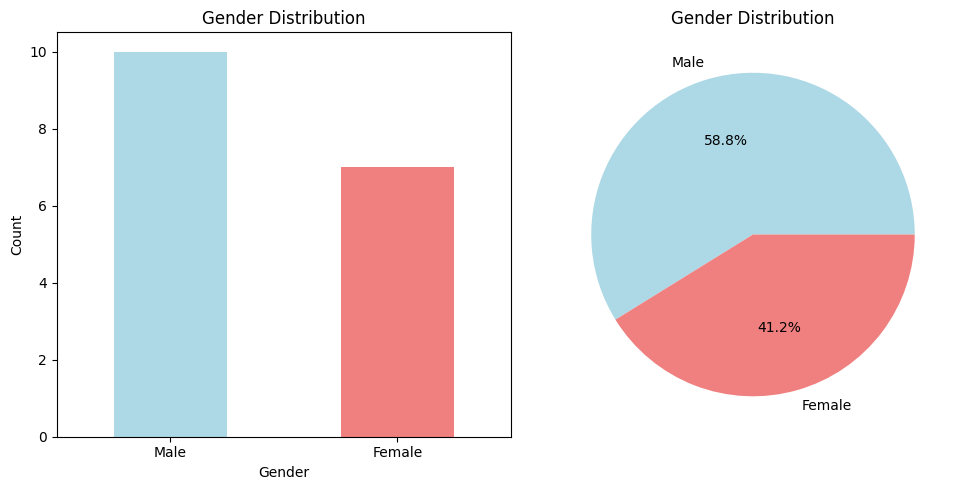

In [6]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
gender_counts.plot(kind='bar', color=['lightblue', 'lightcoral'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Gender Distribution')

plt.tight_layout()
plt.show()

In [7]:
age_counts = df['Age'].value_counts().sort_index()
print("Age Distribution:")
print(age_counts)
print(f"\nAge range: {df['Age'].min()} - {df['Age'].max()}")
print(f"Mean age: {df['Age'].mean():.1f}")
print(f"Median age: {df['Age'].median():.1f}")

Age Distribution:
Age
23    1
25    1
26    4
29    1
30    1
31    1
32    2
40    1
47    1
49    1
54    1
56    1
66    1
Name: count, dtype: int64

Age range: 23 - 66
Mean age: 36.4
Median age: 31.0


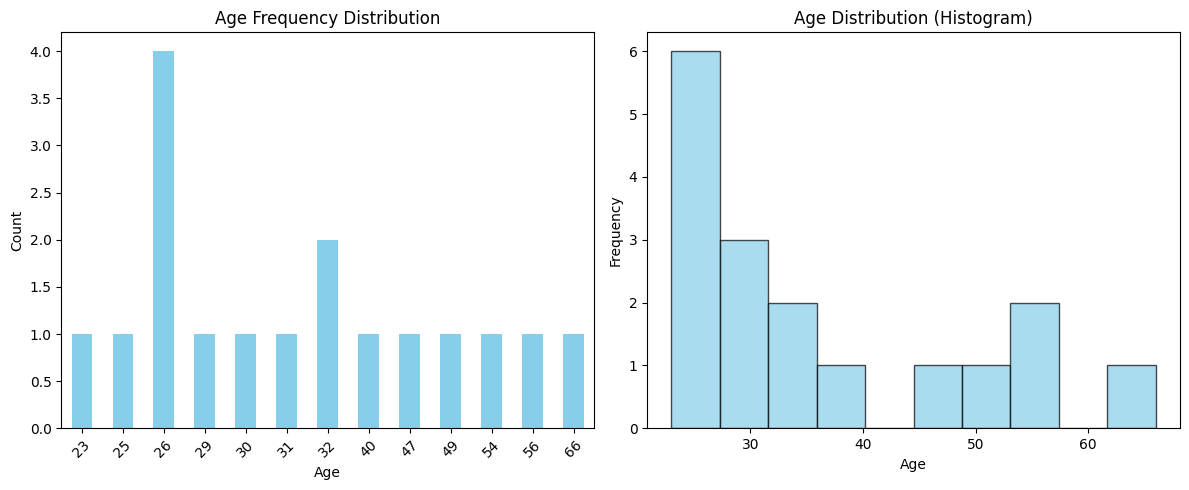

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
age_counts.plot(kind='bar', color='skyblue')
plt.title('Age Frequency Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.hist(df['Age'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Age Distribution (Histogram)')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [9]:
# Combine Education and Education_6_TEXT columns
education_combined = df['Education'].copy()

# Replace 'Other' entries with the text from Education_6_TEXT
other_mask = df['Education'] == 'Other'
education_combined.loc[other_mask] = df.loc[other_mask, 'Education_6_TEXT'].fillna('Other')

education_counts = education_combined.value_counts()
print("Education/Occupation Distribution (including 'Other' details):")
print(education_counts)
print(f"\nTotal participants: {education_counts.sum()}")

Education/Occupation Distribution (including 'Other' details):
Education
Academic/Researcher    6
Manager                6
Data Analyst           4
Healthcare             1
Name: count, dtype: int64

Total participants: 17


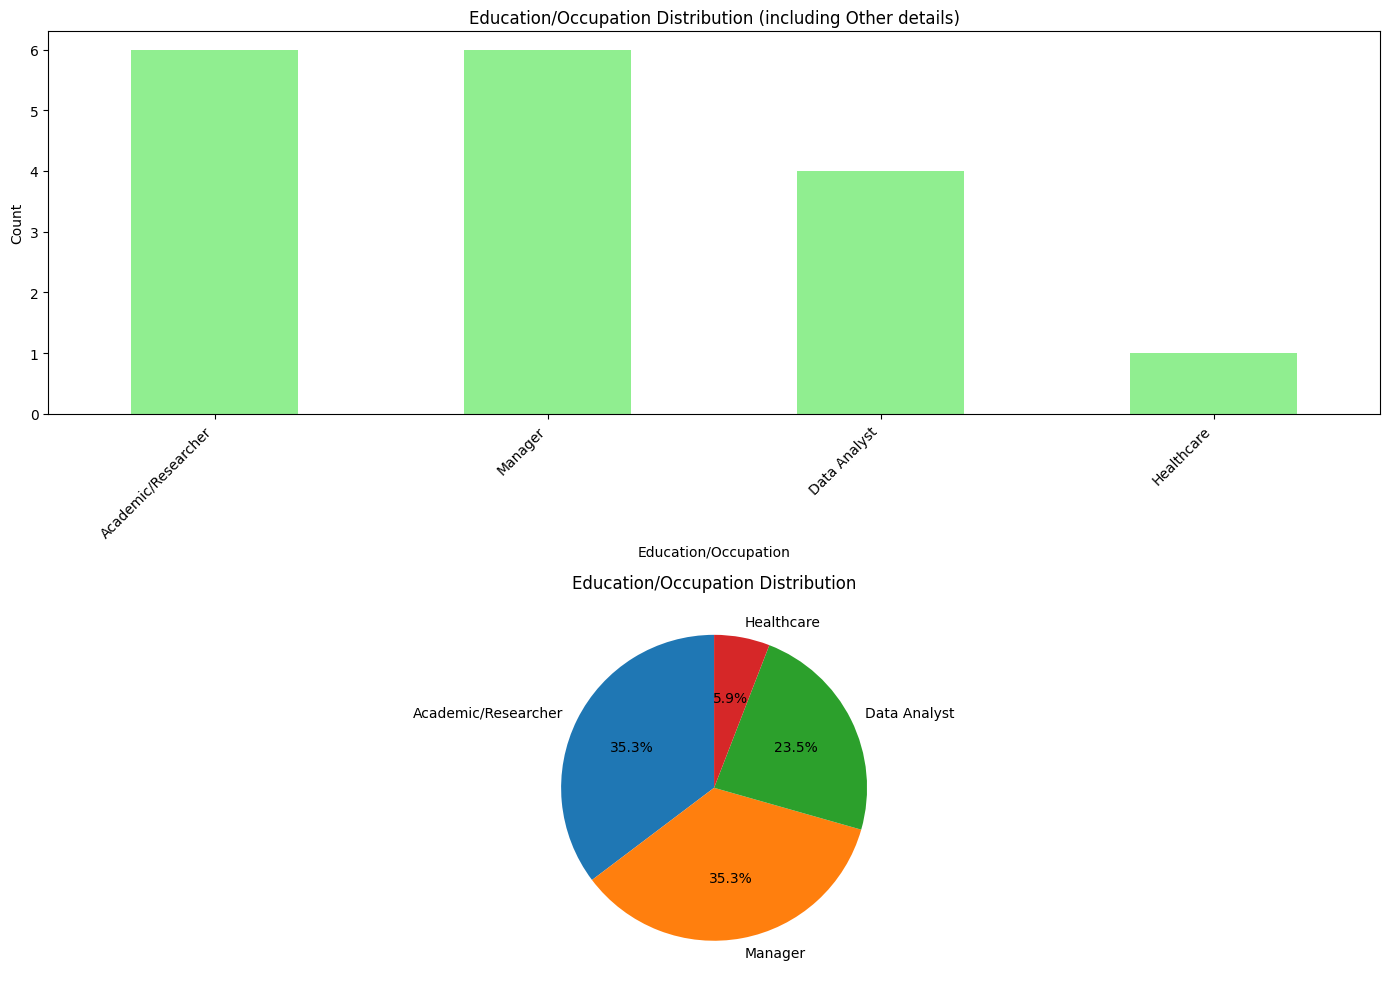

In [10]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
education_counts.plot(kind='bar', color='lightgreen')
plt.title('Education/Occupation Distribution (including Other details)')
plt.xlabel('Education/Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(2, 1, 2)
plt.pie(education_counts.values, labels=education_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Education/Occupation Distribution')

plt.tight_layout()
plt.show()

In [11]:
# Combine Tool and Tool_5_TEXT columns
tool_combined = df['Tool'].copy()

# Replace 'Other' entries with the text from Tool_5_TEXT
other_tool_mask = df['Tool'] == 'Other'
tool_combined.loc[other_tool_mask] = df.loc[other_tool_mask, 'Tool_5_TEXT'].fillna('Other')

tool_counts = tool_combined.value_counts()
print("Tool Usage Distribution (including 'Other' details):")
print(tool_counts)
print(f"\nTotal participants: {tool_counts.sum()}")

Tool Usage Distribution (including 'Other' details):
Tool
Excel / Google Sheets                                                        5
PowerBI,Tableau,Excel / Google Sheets,Programming-based tools (i.e d3.js)    3
PowerBI,Excel / Google Sheets,Programming-based tools (i.e d3.js)            2
Tableau,Excel / Google Sheets                                                2
PowerBI,Excel / Google Sheets,Other                                          1
PowerBI,Excel / Google Sheets                                                1
PowerBI,Tableau                                                              1
Tableau,Excel / Google Sheets,Other                                          1
Programming-based tools (i.e d3.js),Other                                    1
Name: count, dtype: int64

Total participants: 17


In [12]:
# Create a comprehensive tool count by parsing individual tools from combined entries
tool_summary = {}

for tools_entry in tool_combined:
    if pd.isna(tools_entry) or tools_entry == '':
        continue
    
    # Split by comma to handle multiple tools
    individual_tools = [tool.strip() for tool in str(tools_entry).split(',')]
    
    for tool in individual_tools:
        tool = tool.strip()
        if tool in tool_summary:
            tool_summary[tool] += 1
        else:
            tool_summary[tool] = 1

# Convert to sorted series
tool_summary_series = pd.Series(tool_summary).sort_values(ascending=False)

print("Individual Tool Usage Summary:")
print("=" * 40)
for tool, count in tool_summary_series.items():
    print(f"{tool}: {count}")

print(f"\nTotal tool mentions: {tool_summary_series.sum()}")
print(f"Unique tools: {len(tool_summary_series)}")

Individual Tool Usage Summary:
Excel / Google Sheets: 15
PowerBI: 8
Tableau: 7
Programming-based tools (i.e d3.js): 6
Other: 3

Total tool mentions: 39
Unique tools: 5


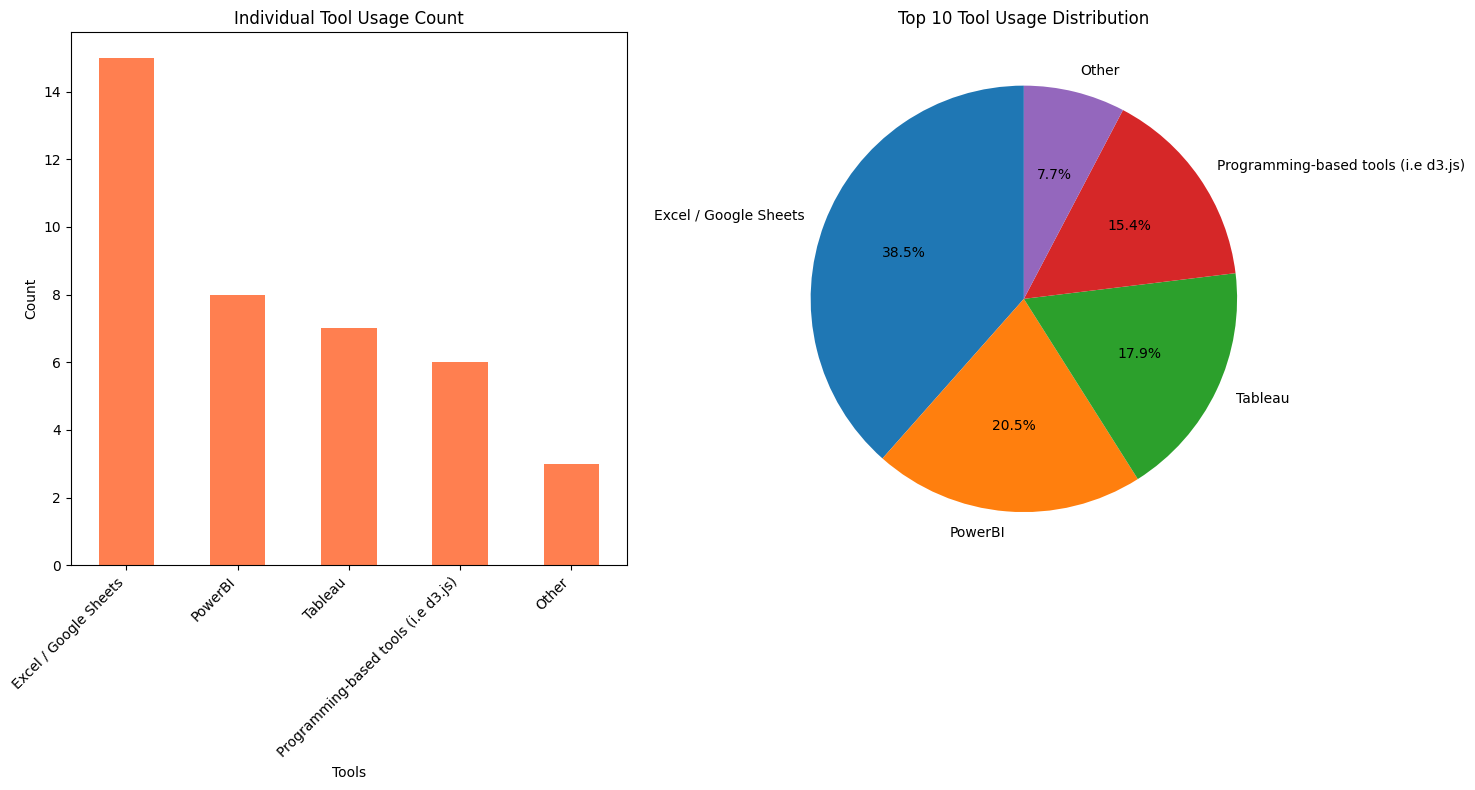

In [13]:
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
tool_summary_series.plot(kind='bar', color='coral')
plt.title('Individual Tool Usage Count')
plt.xlabel('Tools')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
# Only show top tools in pie chart for readability
top_tools = tool_summary_series.head(10)
plt.pie(top_tools.values, labels=top_tools.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 10 Tool Usage Distribution')

plt.tight_layout()
plt.show()

In [14]:
# Extract B-1_1 and NS-1_1 columns for boxplot analysis
# These represent "How easy would it be to find a direction if you started exploring without a specific question using this tool?"

# Define mapping from text responses to numeric scale (1-7)
likert_mapping = {
    'Extremely difficult': 1,
    'Moderately difficult': 2,
    'Slightly difficult': 3,
    'Neither easy nor difficult': 4,
    'Slightly easy': 5,
    'Moderately easy': 6,
    'Extremely easy': 7
}

# Convert text responses to numeric values
b1_scores = df['B-1_1'].map(likert_mapping)
ns1_scores = df['NS-1_1'].map(likert_mapping)

print("B-1_1 (Baseline Tool) - Find direction without specific question:")
print(f"Mean: {b1_scores.mean():.2f}")
print(f"Median: {b1_scores.median():.2f}")
print(f"Min: {b1_scores.min()}, Max: {b1_scores.max()}")
print(f"Valid responses: {b1_scores.count()}")

print("\nNS-1_1 (Narrative Scaffolding) - Find direction without specific question:")
print(f"Mean: {ns1_scores.mean():.2f}")
print(f"Median: {ns1_scores.median():.2f}")
print(f"Min: {ns1_scores.min()}, Max: {ns1_scores.max()}")
print(f"Valid responses: {ns1_scores.count()}")

print("\nResponse distribution:")
print("B-1_1:", dict(b1_scores.value_counts().sort_index()))
print("NS-1_1:", dict(ns1_scores.value_counts().sort_index()))

B-1_1 (Baseline Tool) - Find direction without specific question:
Mean: 2.65
Median: 2.00
Min: 1, Max: 6
Valid responses: 17

NS-1_1 (Narrative Scaffolding) - Find direction without specific question:
Mean: 5.47
Median: 6.00
Min: 2, Max: 7
Valid responses: 17

Response distribution:
B-1_1: {1: 4, 2: 6, 3: 2, 4: 3, 5: 1, 6: 1}
NS-1_1: {2: 1, 3: 1, 5: 4, 6: 9, 7: 2}


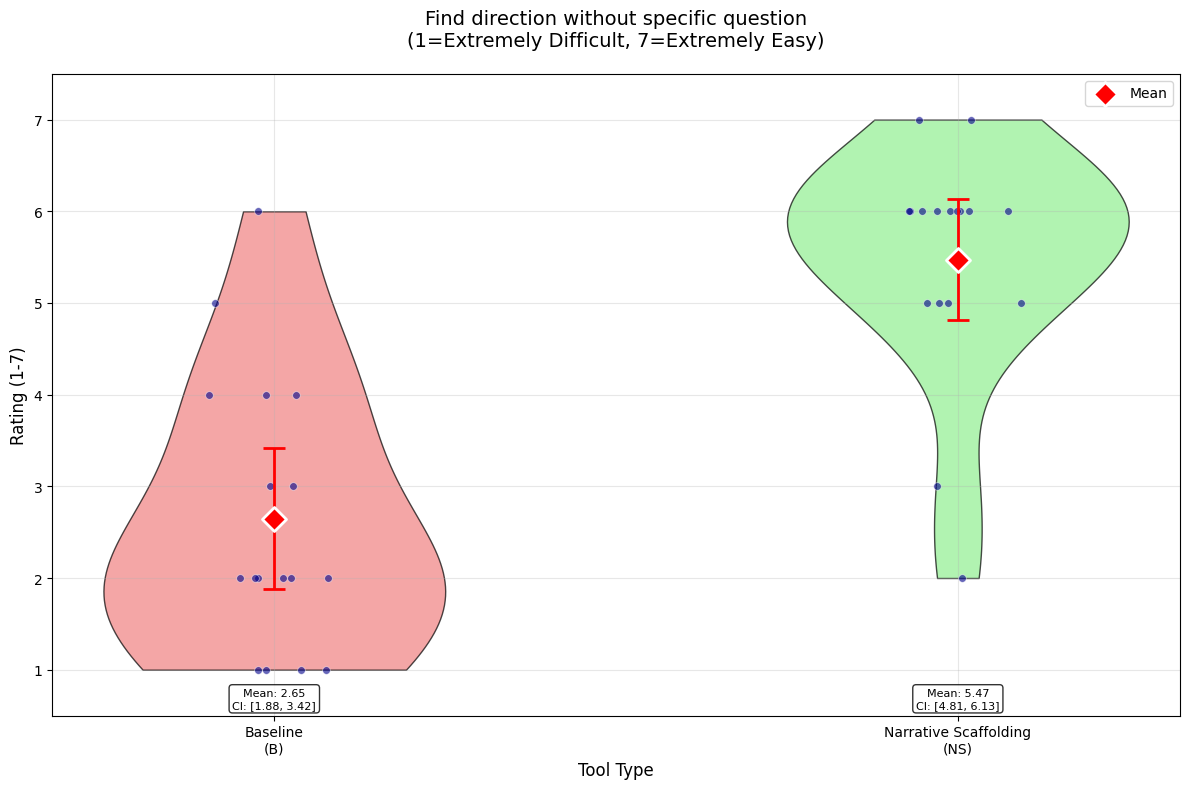


Comparison Summary with 95% Confidence Intervals:
Baseline Tool (B-1) Mean: 2.65, CI: [1.88, 3.42]
Narrative Scaffolding (NS-1) Mean: 5.47, CI: [4.81, 6.13]
Difference (NS-1 - B-1): 2.82


In [15]:
# Create violin plot comparison
import numpy as np
from scipy import stats

plt.figure(figsize=(12, 8))

# Prepare data for violin plot
baseline_data = b1_scores.dropna()
novel_data = ns1_scores.dropna()

# Create combined dataset for violin plot
all_data = [baseline_data, novel_data]
positions = [1, 2]

# Create violin plot
violin_parts = plt.violinplot(all_data, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching NASA-TLX style)
colors = ['lightcoral', 'lightgreen']
for pc, color in zip(violin_parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter
np.random.seed(42)  # For reproducible jitter
for j, (dataset, pos) in enumerate(zip(all_data, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, len(dataset))
    plt.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean = baseline_data.mean()
novel_mean = novel_data.mean()

# 95% confidence intervals
baseline_ci = stats.t.interval(0.95, len(baseline_data)-1, loc=baseline_mean, scale=stats.sem(baseline_data))
novel_ci = stats.t.interval(0.95, len(novel_data)-1, loc=novel_mean, scale=stats.sem(novel_data))

# Add mean markers
plt.scatter([1], [baseline_mean], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
plt.scatter([2], [novel_mean], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
plt.errorbar([1], [baseline_mean], yerr=[[baseline_mean - baseline_ci[0]], [baseline_ci[1] - baseline_mean]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
plt.errorbar([2], [novel_mean], yerr=[[novel_mean - novel_ci[0]], [novel_ci[1] - novel_mean]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot
plt.xticks([1, 2], ['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
plt.title('Find direction without specific question\n(1=Extremely Difficult, 7=Extremely Easy)', fontsize=14, pad=20)
plt.ylabel('Rating (1-7)', fontsize=12)
plt.xlabel('Tool Type', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 7.5)

# Add text annotations for means and CIs
plt.text(1, 0.8, f'Mean: {baseline_mean:.2f}\nCI: [{baseline_ci[0]:.2f}, {baseline_ci[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(2, 0.8, f'Mean: {novel_mean:.2f}\nCI: [{novel_ci[0]:.2f}, {novel_ci[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print comparison with confidence intervals
print(f"\nComparison Summary with 95% Confidence Intervals:")
print(f"Baseline Tool (B-1) Mean: {baseline_mean:.2f}, CI: [{baseline_ci[0]:.2f}, {baseline_ci[1]:.2f}]")
print(f"Narrative Scaffolding (NS-1) Mean: {novel_mean:.2f}, CI: [{novel_ci[0]:.2f}, {novel_ci[1]:.2f}]")
print(f"Difference (NS-1 - B-1): {novel_mean - baseline_mean:.2f}")

In [16]:
# Extract B-3_1 and NS-3_1 columns for boxplot analysis
# These represent "How easy would it be to turn your exploration into a structured output (like a clear recommendation or narrative) using this tool?"

# Convert text responses to numeric values using the same mapping
b3_scores = df['B-3_1'].map(likert_mapping)
ns3_scores = df['NS-3_1'].map(likert_mapping)

print("B-3_1 (Baseline Tool) - Turn exploration into structured output:")
print(f"Mean: {b3_scores.mean():.2f}")
print(f"Median: {b3_scores.median():.2f}")
print(f"Min: {b3_scores.min()}, Max: {b3_scores.max()}")
print(f"Valid responses: {b3_scores.count()}")

print("\nNS-3_1 (Narrative Scaffolding) - Turn exploration into structured output:")
print(f"Mean: {ns3_scores.mean():.2f}")
print(f"Median: {ns3_scores.median():.2f}")
print(f"Min: {ns3_scores.min()}, Max: {ns3_scores.max()}")
print(f"Valid responses: {ns3_scores.count()}")

print("\nResponse distribution:")
print("B-3_1:", dict(b3_scores.value_counts().sort_index()))
print("NS-3_1:", dict(ns3_scores.value_counts().sort_index()))

B-3_1 (Baseline Tool) - Turn exploration into structured output:
Mean: 3.71
Median: 3.00
Min: 2, Max: 7
Valid responses: 17

NS-3_1 (Narrative Scaffolding) - Turn exploration into structured output:
Mean: 5.47
Median: 6.00
Min: 3, Max: 7
Valid responses: 17

Response distribution:
B-3_1: {2: 4, 3: 6, 4: 2, 5: 3, 7: 2}
NS-3_1: {3: 2, 4: 1, 5: 4, 6: 7, 7: 3}


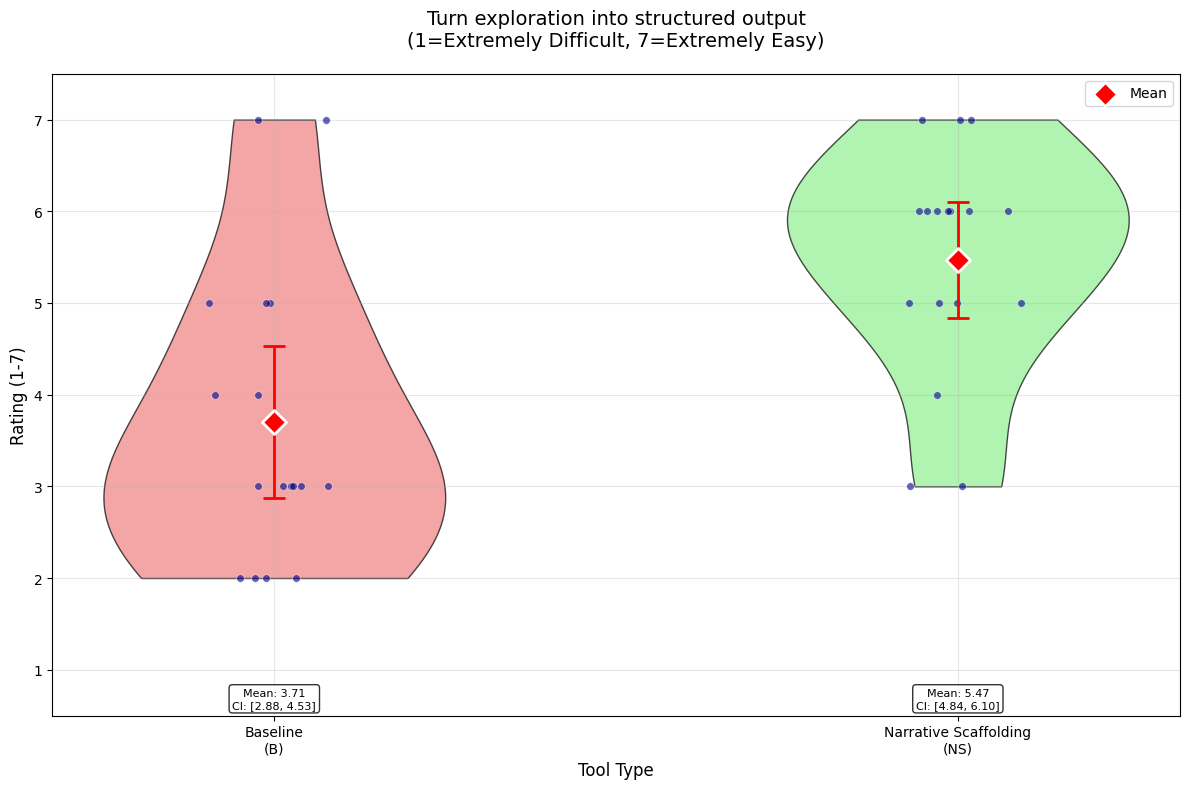


Comparison Summary with 95% Confidence Intervals:
Baseline Tool (B-3) Mean: 3.71, CI: [2.88, 4.53]
Narrative Scaffolding (NS-3) Mean: 5.47, CI: [4.84, 6.10]
Difference (NS-3 - B-3): 1.76


In [17]:
# Create violin plot comparison for structured output question
plt.figure(figsize=(12, 8))

# Prepare data for violin plot
baseline_data_b3 = b3_scores.dropna()
novel_data_b3 = ns3_scores.dropna()

# Create combined dataset for violin plot
all_data_b3 = [baseline_data_b3, novel_data_b3]
positions = [1, 2]

# Create violin plot
violin_parts_b3 = plt.violinplot(all_data_b3, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching NASA-TLX style)
colors = ['lightcoral', 'lightgreen']
for pc, color in zip(violin_parts_b3['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter
np.random.seed(42)  # For reproducible jitter
for j, (dataset, pos) in enumerate(zip(all_data_b3, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, len(dataset))
    plt.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean_b3 = baseline_data_b3.mean()
novel_mean_b3 = novel_data_b3.mean()

# 95% confidence intervals
baseline_ci_b3 = stats.t.interval(0.95, len(baseline_data_b3)-1, loc=baseline_mean_b3, scale=stats.sem(baseline_data_b3))
novel_ci_b3 = stats.t.interval(0.95, len(novel_data_b3)-1, loc=novel_mean_b3, scale=stats.sem(novel_data_b3))

# Add mean markers
plt.scatter([1], [baseline_mean_b3], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
plt.scatter([2], [novel_mean_b3], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
plt.errorbar([1], [baseline_mean_b3], yerr=[[baseline_mean_b3 - baseline_ci_b3[0]], [baseline_ci_b3[1] - baseline_mean_b3]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
plt.errorbar([2], [novel_mean_b3], yerr=[[novel_mean_b3 - novel_ci_b3[0]], [novel_ci_b3[1] - novel_mean_b3]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot
plt.xticks([1, 2], ['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
plt.title('Turn exploration into structured output\n(1=Extremely Difficult, 7=Extremely Easy)', fontsize=14, pad=20)
plt.ylabel('Rating (1-7)', fontsize=12)
plt.xlabel('Tool Type', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 7.5)

# Add text annotations for means and CIs
plt.text(1, 0.8, f'Mean: {baseline_mean_b3:.2f}\nCI: [{baseline_ci_b3[0]:.2f}, {baseline_ci_b3[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(2, 0.8, f'Mean: {novel_mean_b3:.2f}\nCI: [{novel_ci_b3[0]:.2f}, {novel_ci_b3[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print comparison with confidence intervals
print(f"\nComparison Summary with 95% Confidence Intervals:")
print(f"Baseline Tool (B-3) Mean: {baseline_mean_b3:.2f}, CI: [{baseline_ci_b3[0]:.2f}, {baseline_ci_b3[1]:.2f}]")
print(f"Narrative Scaffolding (NS-3) Mean: {novel_mean_b3:.2f}, CI: [{novel_ci_b3[0]:.2f}, {novel_ci_b3[1]:.2f}]")
print(f"Difference (NS-3 - B-3): {novel_mean_b3 - baseline_mean_b3:.2f}")

In [18]:
# Statistical Tests for Both Comparisons
from scipy import stats
import numpy as np

print("=" * 60)
print("STATISTICAL TESTS FOR BASELINE vs Narrative Scaffolding COMPARISONS")
print("=" * 60)

# Test 1: B-1_1 vs NS-1_1 (Find direction without specific question)
print("\n1. FINDING DIRECTION WITHOUT SPECIFIC QUESTION (B-1 vs NS-1)")
print("-" * 55)

# Paired t-test (since same participants used both systems)
t_stat_1, p_value_1 = stats.ttest_rel(b1_scores.dropna(), ns1_scores.dropna())

# Effect size (Cohen's d for paired samples)
diff_scores_1 = ns1_scores.dropna() - b1_scores.dropna()
cohen_d_1 = diff_scores_1.mean() / diff_scores_1.std()

print(f"Paired t-test results:")
print(f"  t-statistic: {t_stat_1:.4f}")
print(f"  p-value: {p_value_1:.6f}")
print(f"  Effect size (Cohen's d): {cohen_d_1:.4f}")

# Wilcoxon signed-rank test (non-parametric alternative)
wilcoxon_stat_1, wilcoxon_p_1 = stats.wilcoxon(b1_scores.dropna(), ns1_scores.dropna())
print(f"\nWilcoxon signed-rank test:")
print(f"  Statistic: {wilcoxon_stat_1}")
print(f"  p-value: {wilcoxon_p_1:.6f}")

# Test 2: B-3_1 vs NS-3_1 (Turn exploration into structured output)
print("\n\n2. TURN EXPLORATION INTO STRUCTURED OUTPUT (B-3 vs NS-3)")
print("-" * 55)

# Paired t-test
t_stat_3, p_value_3 = stats.ttest_rel(b3_scores.dropna(), ns3_scores.dropna())

# Effect size (Cohen's d for paired samples)
diff_scores_3 = ns3_scores.dropna() - b3_scores.dropna()
cohen_d_3 = diff_scores_3.mean() / diff_scores_3.std()

print(f"Paired t-test results:")
print(f"  t-statistic: {t_stat_3:.4f}")
print(f"  p-value: {p_value_3:.6f}")
print(f"  Effect size (Cohen's d): {cohen_d_3:.4f}")

# Wilcoxon signed-rank test
wilcoxon_stat_3, wilcoxon_p_3 = stats.wilcoxon(b3_scores.dropna(), ns3_scores.dropna())
print(f"\nWilcoxon signed-rank test:")
print(f"  Statistic: {wilcoxon_stat_3}")
print(f"  p-value: {wilcoxon_p_3:.6f}")

# Summary
print("\n\n" + "=" * 60)
print("SUMMARY OF STATISTICAL RESULTS")
print("=" * 60)

alpha = 0.05
print(f"Significance level: α = {alpha}")
print(f"\nEffect size interpretation (Cohen's d):")
print(f"  Small: 0.2, Medium: 0.5, Large: 0.8")

print(f"\n1. Finding Direction (B-1 vs NS-1):")
print(f"   - Mean difference: {ns1_scores.mean() - b1_scores.mean():.2f}")
print(f"   - p-value: {p_value_1:.6f} {'***' if p_value_1 < 0.001 else '**' if p_value_1 < 0.01 else '*' if p_value_1 < 0.05 else 'ns'}")
print(f"   - Effect size: {cohen_d_1:.3f} ({'Large' if abs(cohen_d_1) >= 0.8 else 'Medium' if abs(cohen_d_1) >= 0.5 else 'Small' if abs(cohen_d_1) >= 0.2 else 'Negligible'})")
print(f"   - Significant: {'Yes' if p_value_1 < alpha else 'No'}")

print(f"\n2. Structured Output (B-3 vs NS-3):")
print(f"   - Mean difference: {ns3_scores.mean() - b3_scores.mean():.2f}")
print(f"   - p-value: {p_value_3:.6f} {'***' if p_value_3 < 0.001 else '**' if p_value_3 < 0.01 else '*' if p_value_3 < 0.05 else 'ns'}")
print(f"   - Effect size: {cohen_d_3:.3f} ({'Large' if abs(cohen_d_3) >= 0.8 else 'Medium' if abs(cohen_d_3) >= 0.5 else 'Small' if abs(cohen_d_3) >= 0.2 else 'Negligible'})")
print(f"   - Significant: {'Yes' if p_value_3 < alpha else 'No'}")

print(f"\nNote: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

STATISTICAL TESTS FOR BASELINE vs Narrative Scaffolding COMPARISONS

1. FINDING DIRECTION WITHOUT SPECIFIC QUESTION (B-1 vs NS-1)
-------------------------------------------------------
Paired t-test results:
  t-statistic: -6.5548
  p-value: 0.000007
  Effect size (Cohen's d): 1.5898

Wilcoxon signed-rank test:
  Statistic: 2.0
  p-value: 0.000560


2. TURN EXPLORATION INTO STRUCTURED OUTPUT (B-3 vs NS-3)
-------------------------------------------------------
Paired t-test results:
  t-statistic: -3.2326
  p-value: 0.005208
  Effect size (Cohen's d): 0.7840

Wilcoxon signed-rank test:
  Statistic: 22.0
  p-value: 0.007904


SUMMARY OF STATISTICAL RESULTS
Significance level: α = 0.05

Effect size interpretation (Cohen's d):
  Small: 0.2, Medium: 0.5, Large: 0.8

1. Finding Direction (B-1 vs NS-1):
   - Mean difference: 2.82
   - p-value: 0.000007 ***
   - Effect size: 1.590 (Large)
   - Significant: Yes

2. Structured Output (B-3 vs NS-3):
   - Mean difference: 1.76
   - p-value: 0.00

In [19]:
# NASA-TLX Analysis: B-5_1, B-6_1, B-7_1, B-8_1 vs NS-5_1, NS-6_1, NS-7_1, NS-8_1
print("=" * 60)
print("NASA-TLX ANALYSIS: BASELINE vs Narrative Scaffolding")
print("=" * 60)

# Define NASA-TLX question mappings (corrected order)
nasatlx_questions = {
    '5': 'Mental Demand',
    '6': 'Performance', 
    '7': 'Effort',
    '8': 'Frustration'
}

# NASA-TLX mapping: Extremely easy = 1 (extremely low), Extremely difficult = 7 (extremely high)
# Lower scores = better performance (less demand/effort/frustration)
# Note: For Performance, the interpretation may differ - need to check context
nasatlx_mapping = {
    'Extremely easy': 1,      # Extremely low
    'Moderately easy': 2,     # Very low  
    'Slightly easy': 3,       # Low
    'Neither easy nor difficult': 4,  # Moderate
    'Slightly difficult': 5,  # High
    'Moderately difficult': 6, # Very high
    'Extremely difficult': 7   # Extremely high
}

print("NASA-TLX Scale: 1=Extremely Low, 7=Extremely High")
print("Note: Lower scores = Better for Mental Demand, Effort, Frustration")
print("      Performance interpretation may vary based on question context")

# Convert all NASA-TLX responses to numeric values
nasatlx_data = {}

for q_num in ['5', '6', '7', '8']:
    b_col = f'B-{q_num}_1'
    ns_col = f'NS-{q_num}_1'
    
    b_scores = df[b_col].map(nasatlx_mapping)
    ns_scores = df[ns_col].map(nasatlx_mapping)
    
    nasatlx_data[q_num] = {
        'baseline': b_scores,
        'novel': ns_scores,
        'question': nasatlx_questions[q_num]
    }
    
    print(f"\n{nasatlx_questions[q_num]} (Question {q_num}):")
    print(f"  Baseline (B-{q_num}_1) - Mean: {b_scores.mean():.2f}, Median: {b_scores.median():.2f}")
    print(f"  Narrative Scaffolding (NS-{q_num}_1) - Mean: {ns_scores.mean():.2f}, Median: {ns_scores.median():.2f}")
    print(f"  Difference (NS - B): {ns_scores.mean() - b_scores.mean():.2f}")
    
    # For NASA-TLX, lower scores are generally better (except potentially for Performance)
    if ns_scores.mean() < b_scores.mean():
        improvement = "Better (Lower)"
    elif ns_scores.mean() > b_scores.mean():
        improvement = "Worse (Higher)"
    else:
        improvement = "Same"
    print(f"  Narrative Scaffolding is: {improvement}")

print(f"\nInterpretation: Lower NASA-TLX scores generally = Better performance")

NASA-TLX ANALYSIS: BASELINE vs Narrative Scaffolding
NASA-TLX Scale: 1=Extremely Low, 7=Extremely High
Note: Lower scores = Better for Mental Demand, Effort, Frustration
      Performance interpretation may vary based on question context

Mental Demand (Question 5):
  Baseline (B-5_1) - Mean: 4.41, Median: 5.00
  Narrative Scaffolding (NS-5_1) - Mean: 2.82, Median: 2.00
  Difference (NS - B): -1.59
  Narrative Scaffolding is: Better (Lower)

Performance (Question 6):
  Baseline (B-6_1) - Mean: 3.35, Median: 3.00
  Narrative Scaffolding (NS-6_1) - Mean: 2.29, Median: 2.00
  Difference (NS - B): -1.06
  Narrative Scaffolding is: Better (Lower)

Effort (Question 7):
  Baseline (B-7_1) - Mean: 4.47, Median: 5.00
  Narrative Scaffolding (NS-7_1) - Mean: 2.82, Median: 3.00
  Difference (NS - B): -1.65
  Narrative Scaffolding is: Better (Lower)

Frustration (Question 8):
  Baseline (B-8_1) - Mean: 4.76, Median: 5.00
  Narrative Scaffolding (NS-8_1) - Mean: 3.00, Median: 3.00
  Difference (NS 

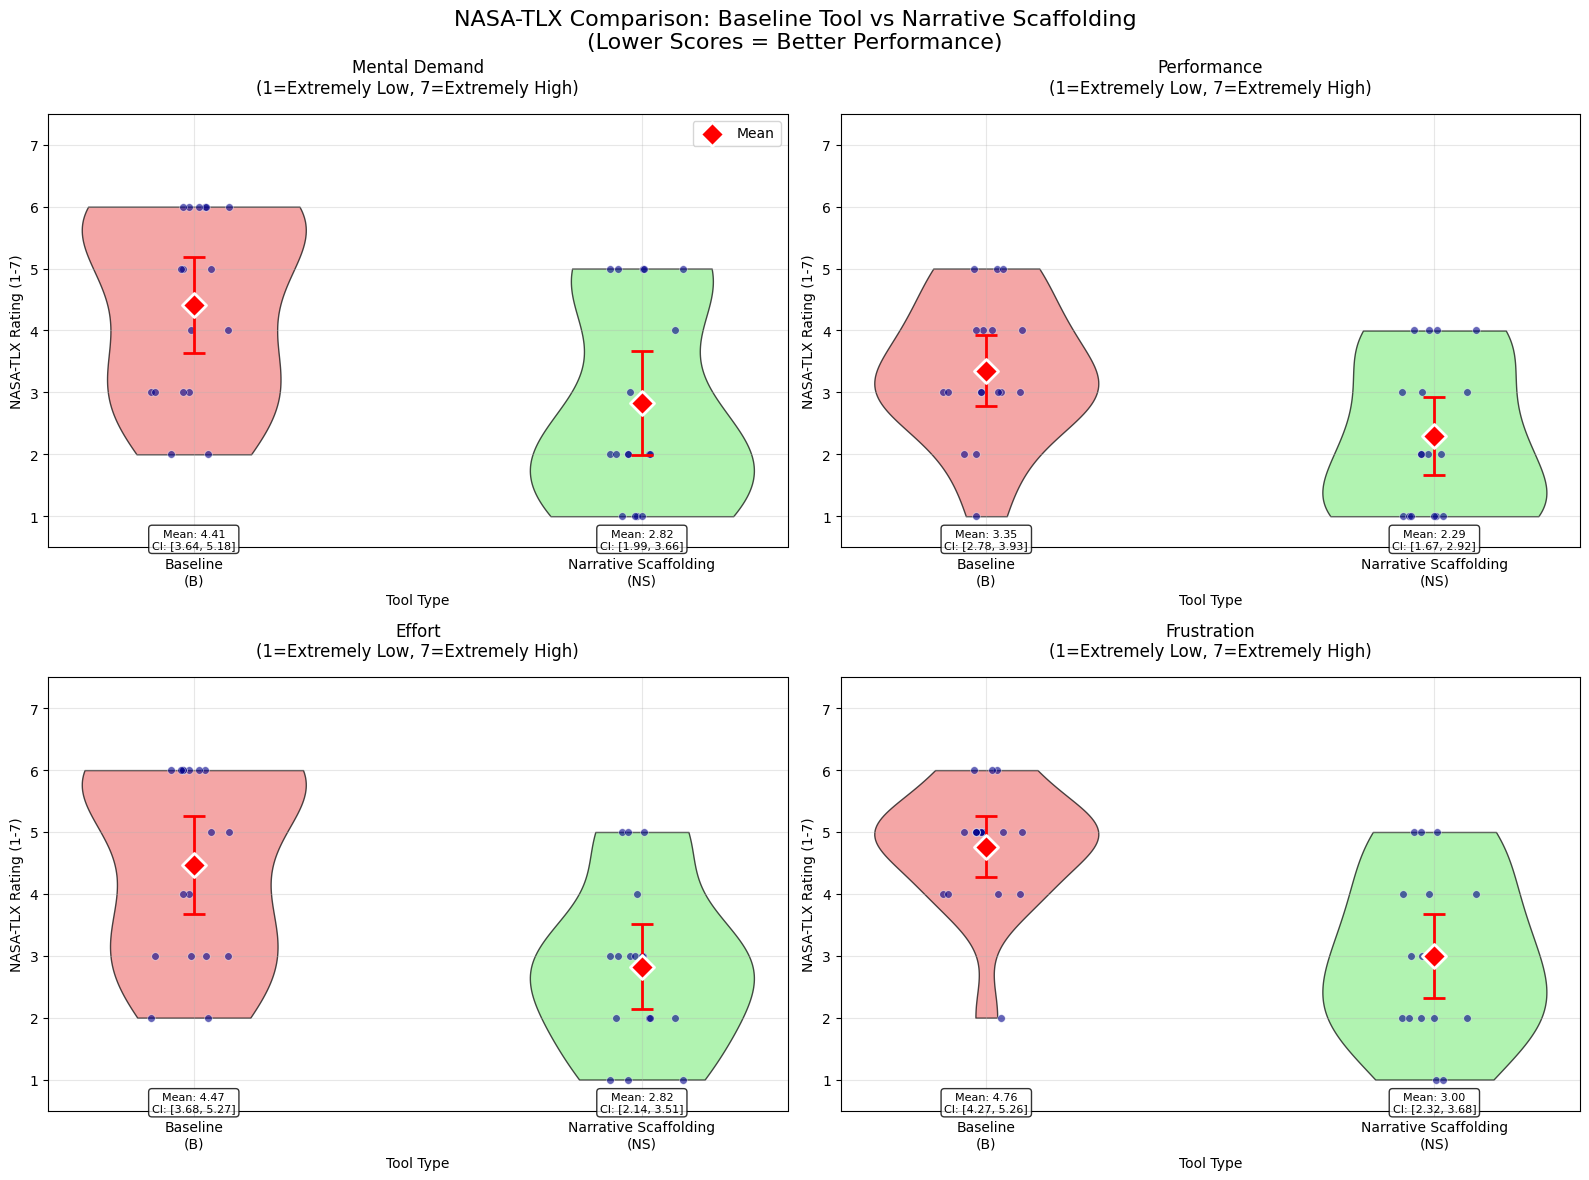


NASA-TLX Summary with 95% Confidence Intervals (Lower = Better):
Dimension       B Mean   B CI                 NS Mean  NS CI                Diff     Winner    
--------------------------------------------------------------------------------
Mental Demand   4.41     [3.64, 5.18]    2.82     [1.99, 3.66]    -1.59    NS Better 
Performance     3.35     [2.78, 3.93]    2.29     [1.67, 2.92]    -1.06    NS Better 
Effort          4.47     [3.68, 5.27]    2.82     [2.14, 3.51]    -1.65    NS Better 
Frustration     4.76     [4.27, 5.26]    3.00     [2.32, 3.68]    -1.76    NS Better 

Note: Lower scores indicate better performance (less demand/effort/frustration)
CI = 95% Confidence Interval


In [20]:
# NASA-TLX Visualizations with Violin Plots
import numpy as np
from scipy import stats

plt.figure(figsize=(16, 12))

for i, (q_num, data) in enumerate(nasatlx_data.items(), 1):
    plt.subplot(2, 2, i)
    
    # Prepare data for violin plot
    baseline_data = data['baseline'].dropna()
    novel_data = data['novel'].dropna()
    
    # Create combined dataset for violin plot
    all_data = [baseline_data, novel_data]
    positions = [1, 2]
    
    # Create violin plot
    violin_parts = plt.violinplot(all_data, positions=positions, showmeans=False, showmedians=False, showextrema=False)
    
    # Customize violin colors
    colors = ['lightcoral', 'lightgreen']
    for pc, color in zip(violin_parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)
    
    # Add individual data points with jitter
    np.random.seed(42)  # For reproducible jitter
    for j, (dataset, pos) in enumerate(zip(all_data, positions)):
        # Add small random jitter to x-coordinates
        x_jitter = np.random.normal(pos, 0.05, len(dataset))
        plt.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)
    
    # Calculate means and confidence intervals
    baseline_mean = baseline_data.mean()
    novel_mean = novel_data.mean()
    
    # 95% confidence intervals
    baseline_ci = stats.t.interval(0.95, len(baseline_data)-1, loc=baseline_mean, scale=stats.sem(baseline_data))
    novel_ci = stats.t.interval(0.95, len(novel_data)-1, loc=novel_mean, scale=stats.sem(novel_data))
    
    # Add mean markers
    plt.scatter([1], [baseline_mean], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
    plt.scatter([2], [novel_mean], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)
    
    # Add confidence interval error bars
    plt.errorbar([1], [baseline_mean], yerr=[[baseline_mean - baseline_ci[0]], [baseline_ci[1] - baseline_mean]], 
                color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
    plt.errorbar([2], [novel_mean], yerr=[[novel_mean - novel_ci[0]], [novel_ci[1] - novel_mean]], 
                color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
    
    # Customize plot
    plt.xticks([1, 2], ['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
    plt.title(f'{data["question"]}\n(1=Extremely Low, 7=Extremely High)', fontsize=12, pad=15)
    plt.ylabel('NASA-TLX Rating (1-7)', fontsize=10)
    plt.xlabel('Tool Type', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.ylim(0.5, 7.5)
    
    # Add text annotations for means and CIs
    plt.text(1, 0.8, f'Mean: {baseline_mean:.2f}\nCI: [{baseline_ci[0]:.2f}, {baseline_ci[1]:.2f}]', 
             ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    plt.text(2, 0.8, f'Mean: {novel_mean:.2f}\nCI: [{novel_ci[0]:.2f}, {novel_ci[1]:.2f}]', 
             ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    if i == 1:  # Only show legend on first subplot
        plt.legend(loc='upper right')

plt.suptitle('NASA-TLX Comparison: Baseline Tool vs Narrative Scaffolding\n(Lower Scores = Better Performance)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# Print summary for all NASA-TLX dimensions with confidence intervals
print("\nNASA-TLX Summary with 95% Confidence Intervals (Lower = Better):")
print("=" * 80)
print(f"{'Dimension':<15} {'B Mean':<8} {'B CI':<20} {'NS Mean':<8} {'NS CI':<20} {'Diff':<8} {'Winner':<10}")
print("-" * 80)

for q_num, data in nasatlx_data.items():
    baseline_data = data['baseline'].dropna()
    novel_data = data['novel'].dropna()
    
    b_mean = baseline_data.mean()
    ns_mean = novel_data.mean()
    diff = ns_mean - b_mean
    
    # Calculate 95% confidence intervals
    b_ci = stats.t.interval(0.95, len(baseline_data)-1, loc=b_mean, scale=stats.sem(baseline_data))
    ns_ci = stats.t.interval(0.95, len(novel_data)-1, loc=ns_mean, scale=stats.sem(novel_data))
    
    # Determine which system is better
    if ns_mean < b_mean:
        better_system = "NS Better"
    elif ns_mean > b_mean:
        better_system = "B Better" 
    else:
        better_system = "Same"
    
    print(f"{data['question']:<15} {b_mean:<8.2f} [{b_ci[0]:.2f}, {b_ci[1]:.2f}]    {ns_mean:<8.2f} [{ns_ci[0]:.2f}, {ns_ci[1]:.2f}]    {diff:<+8.2f} {better_system:<10}")

print(f"\nNote: Lower scores indicate better performance (less demand/effort/frustration)")
print(f"CI = 95% Confidence Interval")

In [21]:
# Statistical Tests for NASA-TLX Comparisons
print("\n" + "=" * 60)
print("STATISTICAL TESTS FOR NASA-TLX COMPARISONS")
print("=" * 60)

nasa_results = {}

for q_num, data in nasatlx_data.items():
    print(f"\n{data['question'].upper()} (Question {q_num})")
    print("-" * 50)
    
    baseline = data['baseline'].dropna()
    novel = data['novel'].dropna()
    
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(baseline, novel)
    
    # Effect size (Cohen's d for paired samples)
    diff_scores = novel - baseline
    cohen_d = diff_scores.mean() / diff_scores.std()
    
    # Wilcoxon signed-rank test
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(baseline, novel)
    
    nasa_results[q_num] = {
        'question': data['question'],
        'baseline_mean': baseline.mean(),
        'novel_mean': novel.mean(),
        'mean_diff': novel.mean() - baseline.mean(),
        't_stat': t_stat,
        'p_value': p_value,
        'cohen_d': cohen_d,
        'wilcoxon_p': wilcoxon_p
    }
    
    print(f"Paired t-test:")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Effect size (Cohen's d): {cohen_d:.4f}")
    
    print(f"Wilcoxon signed-rank test:")
    print(f"  p-value: {wilcoxon_p:.6f}")
    
    # Interpretation
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    effect_size_label = "Large" if abs(cohen_d) >= 0.8 else "Medium" if abs(cohen_d) >= 0.5 else "Small" if abs(cohen_d) >= 0.2 else "Negligible"
    
    print(f"  Significance: {significance}")
    print(f"  Effect size: {effect_size_label}")

# Summary table
print(f"\n\n" + "=" * 90)
print("NASA-TLX STATISTICAL SUMMARY")
print("=" * 90)
cohens_d_label = "Cohen's d"
print(f"{'Dimension':<15} {'B Mean':<8} {'NS Mean':<8} {'Diff':<8} {'p-value':<10} {cohens_d_label:<10} {'Sig':<5} {'Winner':<10}")
print("-" * 90)

for q_num, results in nasa_results.items():
    significance = "***" if results['p_value'] < 0.001 else "**" if results['p_value'] < 0.01 else "*" if results['p_value'] < 0.05 else "ns"
    
    # Determine winner (lower is better for NASA-TLX)
    if results['novel_mean'] < results['baseline_mean']:
        winner = "Novel" if results['p_value'] < 0.05 else "Novel (ns)"
    elif results['novel_mean'] > results['baseline_mean']:
        winner = "Baseline" if results['p_value'] < 0.05 else "Base (ns)"
    else:
        winner = "Tie"
    
    print(f"{results['question']:<15} {results['baseline_mean']:<8.2f} {results['novel_mean']:<8.2f} "
          f"{results['mean_diff']:<+8.2f} {results['p_value']:<10.6f} {results['cohen_d']:<10.3f} {significance:<5} {winner:<10}")

print(f"\nInterpretation:")
print(f"• Lower NASA-TLX scores = Better performance")
print(f"• Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print(f"• Winner column shows which system performs better (if significant)")

# Key findings
print(f"\nKey NASA-TLX Findings:")
significant_results = []
for q_num, results in nasa_results.items():
    question = results['question']
    diff = results['mean_diff']
    p_val = results['p_value']
    
    if p_val < 0.05:
        if diff < 0:  # Narrative Scaffolding has lower scores = better
            interpretation = "Narrative Scaffolding BETTER"
            significant_results.append(f"✓ {question}: {interpretation} (diff: {diff:.2f}, p: {p_val:.3f})")
        else:  # Narrative Scaffolding has higher scores = worse
            interpretation = "Baseline Tool BETTER"
            significant_results.append(f"✗ {question}: {interpretation} (diff: {diff:.2f}, p: {p_val:.3f})")
    else:
        significant_results.append(f"≈ {question}: No significant difference (diff: {diff:.2f}, p: {p_val:.3f})")

for result in significant_results:
    print(result)


STATISTICAL TESTS FOR NASA-TLX COMPARISONS

MENTAL DEMAND (Question 5)
--------------------------------------------------
Paired t-test:
  t-statistic: 2.7292
  p-value: 0.014857
  Effect size (Cohen's d): -0.6619
Wilcoxon signed-rank test:
  p-value: 0.022326
  Significance: *
  Effect size: Medium

PERFORMANCE (Question 6)
--------------------------------------------------
Paired t-test:
  t-statistic: 2.4962
  p-value: 0.023858
  Effect size (Cohen's d): -0.6054
Wilcoxon signed-rank test:
  p-value: 0.028550
  Significance: *
  Effect size: Medium

EFFORT (Question 7)
--------------------------------------------------
Paired t-test:
  t-statistic: 4.1006
  p-value: 0.000835
  Effect size (Cohen's d): -0.9945
Wilcoxon signed-rank test:
  p-value: 0.003465
  Significance: ***
  Effect size: Large

FRUSTRATION (Question 8)
--------------------------------------------------
Paired t-test:
  t-statistic: 3.9956
  p-value: 0.001042
  Effect size (Cohen's d): -0.9691
Wilcoxon signed-rank 

In [22]:
# Analysis for B-9_1 and NS-9_1: "This tool encouraged you to try different ways of analyzing the same data"
print("=" * 80)
print("ANALYSIS: ENCOURAGES DIFFERENT WAYS OF ANALYZING DATA (B-9 vs NS-9)")
print("=" * 80)

# Convert text responses to numeric values using the same Likert mapping
b9_scores = df['B-9_1'].map(likert_mapping)
ns9_scores = df['NS-9_1'].map(likert_mapping)

print("B-9_1 (Baseline Tool) - Encourages different ways of analyzing:")
print(f"Mean: {b9_scores.mean():.2f}")
print(f"Median: {b9_scores.median():.2f}")
print(f"Min: {b9_scores.min()}, Max: {b9_scores.max()}")
print(f"Valid responses: {b9_scores.count()}")

print("\nNS-9_1 (Narrative Scaffolding) - Encourages different ways of analyzing:")
print(f"Mean: {ns9_scores.mean():.2f}")
print(f"Median: {ns9_scores.median():.2f}")
print(f"Min: {ns9_scores.min()}, Max: {ns9_scores.max()}")
print(f"Valid responses: {ns9_scores.count()}")

print("\nResponse distribution:")
print("B-9_1:", dict(b9_scores.value_counts().sort_index()))
print("NS-9_1:", dict(ns9_scores.value_counts().sort_index()))

ANALYSIS: ENCOURAGES DIFFERENT WAYS OF ANALYZING DATA (B-9 vs NS-9)
B-9_1 (Baseline Tool) - Encourages different ways of analyzing:
Mean: 4.24
Median: 5.00
Min: 1, Max: 7
Valid responses: 17

NS-9_1 (Narrative Scaffolding) - Encourages different ways of analyzing:
Mean: 6.18
Median: 6.00
Min: 4, Max: 7
Valid responses: 17

Response distribution:
B-9_1: {1: 1, 2: 1, 3: 5, 4: 1, 5: 5, 6: 3, 7: 1}
NS-9_1: {4: 1, 5: 3, 6: 5, 7: 8}


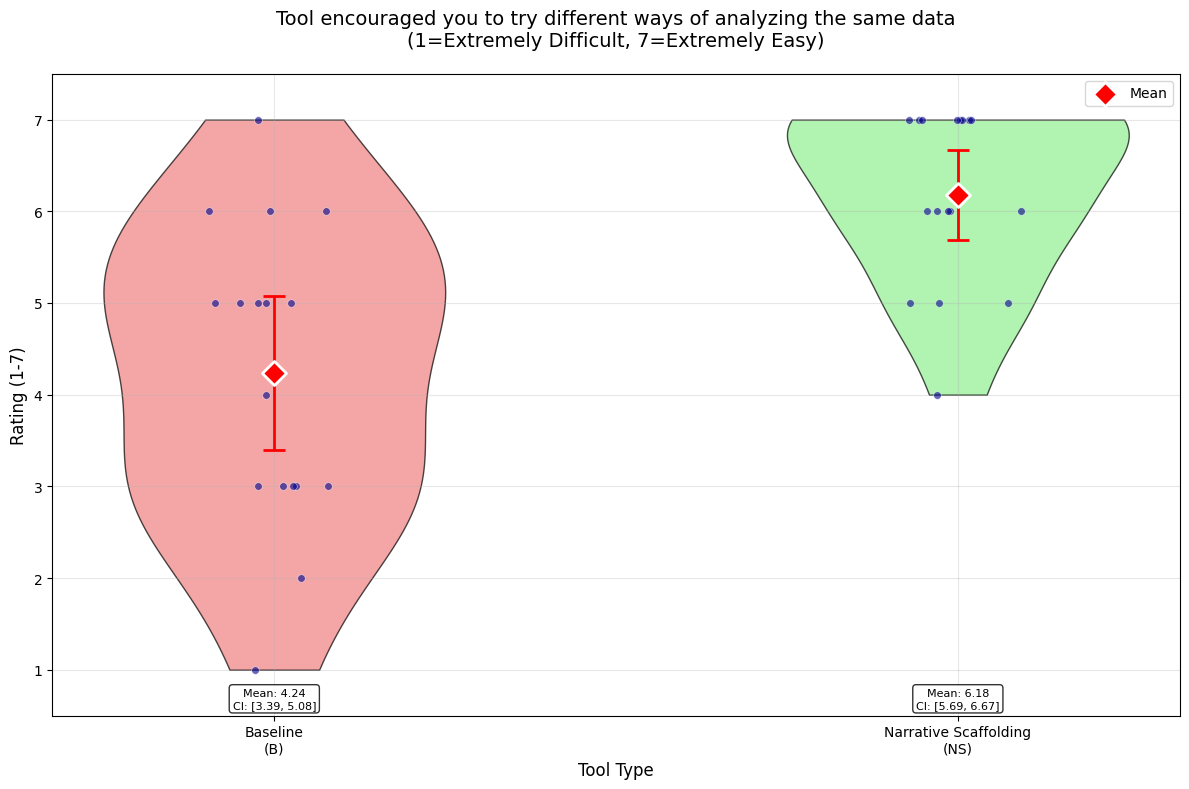


Comparison Summary with 95% Confidence Intervals:
Baseline Tool (B-9) Mean: 4.24, CI: [3.39, 5.08]
Narrative Scaffolding (NS-9) Mean: 6.18, CI: [5.69, 6.67]
Difference (NS-9 - B-9): 1.94


In [23]:
# Create violin plot comparison for B-9/NS-9
plt.figure(figsize=(12, 8))

# Prepare data for violin plot
baseline_data_b9 = b9_scores.dropna()
novel_data_b9 = ns9_scores.dropna()

# Create combined dataset for violin plot
all_data_b9 = [baseline_data_b9, novel_data_b9]
positions = [1, 2]

# Create violin plot
violin_parts_b9 = plt.violinplot(all_data_b9, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching style)
colors = ['lightcoral', 'lightgreen']
for pc, color in zip(violin_parts_b9['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter
np.random.seed(42)  # For reproducible jitter
for j, (dataset, pos) in enumerate(zip(all_data_b9, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, len(dataset))
    plt.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean_b9 = baseline_data_b9.mean()
novel_mean_b9 = novel_data_b9.mean()

# 95% confidence intervals
baseline_ci_b9 = stats.t.interval(0.95, len(baseline_data_b9)-1, loc=baseline_mean_b9, scale=stats.sem(baseline_data_b9))
novel_ci_b9 = stats.t.interval(0.95, len(novel_data_b9)-1, loc=novel_mean_b9, scale=stats.sem(novel_data_b9))

# Add mean markers
plt.scatter([1], [baseline_mean_b9], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
plt.scatter([2], [novel_mean_b9], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
plt.errorbar([1], [baseline_mean_b9], yerr=[[baseline_mean_b9 - baseline_ci_b9[0]], [baseline_ci_b9[1] - baseline_mean_b9]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
plt.errorbar([2], [novel_mean_b9], yerr=[[novel_mean_b9 - novel_ci_b9[0]], [novel_ci_b9[1] - novel_mean_b9]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot
plt.xticks([1, 2], ['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
plt.title('Tool encouraged you to try different ways of analyzing the same data\n(1=Extremely Difficult, 7=Extremely Easy)', fontsize=14, pad=20)
plt.ylabel('Rating (1-7)', fontsize=12)
plt.xlabel('Tool Type', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 7.5)

# Add text annotations for means and CIs
plt.text(1, 0.8, f'Mean: {baseline_mean_b9:.2f}\nCI: [{baseline_ci_b9[0]:.2f}, {baseline_ci_b9[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(2, 0.8, f'Mean: {novel_mean_b9:.2f}\nCI: [{novel_ci_b9[0]:.2f}, {novel_ci_b9[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print comparison with confidence intervals
print(f"\nComparison Summary with 95% Confidence Intervals:")
print(f"Baseline Tool (B-9) Mean: {baseline_mean_b9:.2f}, CI: [{baseline_ci_b9[0]:.2f}, {baseline_ci_b9[1]:.2f}]")
print(f"Narrative Scaffolding (NS-9) Mean: {novel_mean_b9:.2f}, CI: [{novel_ci_b9[0]:.2f}, {novel_ci_b9[1]:.2f}]")
print(f"Difference (NS-9 - B-9): {novel_mean_b9 - baseline_mean_b9:.2f}")

In [24]:
# Analysis for B-11_1 and NS-11_1: "Made it easier to reflect on and contrast alternative perspectives"
print("=" * 80)
print("ANALYSIS: EASIER TO REFLECT ON AND CONTRAST ALTERNATIVE PERSPECTIVES (B-11 vs NS-11)")
print("=" * 80)

# Convert text responses to numeric values using the same Likert mapping
b11_scores = df['B-11_1'].map(likert_mapping)
ns11_scores = df['NS-11_1'].map(likert_mapping)

print("B-11_1 (Baseline Tool) - Easier to reflect on and contrast perspectives:")
print(f"Mean: {b11_scores.mean():.2f}")
print(f"Median: {b11_scores.median():.2f}")
print(f"Min: {b11_scores.min()}, Max: {b11_scores.max()}")
print(f"Valid responses: {b11_scores.count()}")

print("\nNS-11_1 (Narrative Scaffolding) - Easier to reflect on and contrast perspectives:")
print(f"Mean: {ns11_scores.mean():.2f}")
print(f"Median: {ns11_scores.median():.2f}")
print(f"Min: {ns11_scores.min()}, Max: {ns11_scores.max()}")
print(f"Valid responses: {ns11_scores.count()}")

print("\nResponse distribution:")
print("B-11_1:", dict(b11_scores.value_counts().sort_index()))
print("NS-11_1:", dict(ns11_scores.value_counts().sort_index()))

ANALYSIS: EASIER TO REFLECT ON AND CONTRAST ALTERNATIVE PERSPECTIVES (B-11 vs NS-11)
B-11_1 (Baseline Tool) - Easier to reflect on and contrast perspectives:
Mean: 3.41
Median: 3.00
Min: 2, Max: 7
Valid responses: 17

NS-11_1 (Narrative Scaffolding) - Easier to reflect on and contrast perspectives:
Mean: 5.71
Median: 6.00
Min: 3, Max: 7
Valid responses: 17

Response distribution:
B-11_1: {2: 7, 3: 3, 4: 4, 6: 2, 7: 1}
NS-11_1: {3: 1, 4: 2, 5: 3, 6: 6, 7: 5}


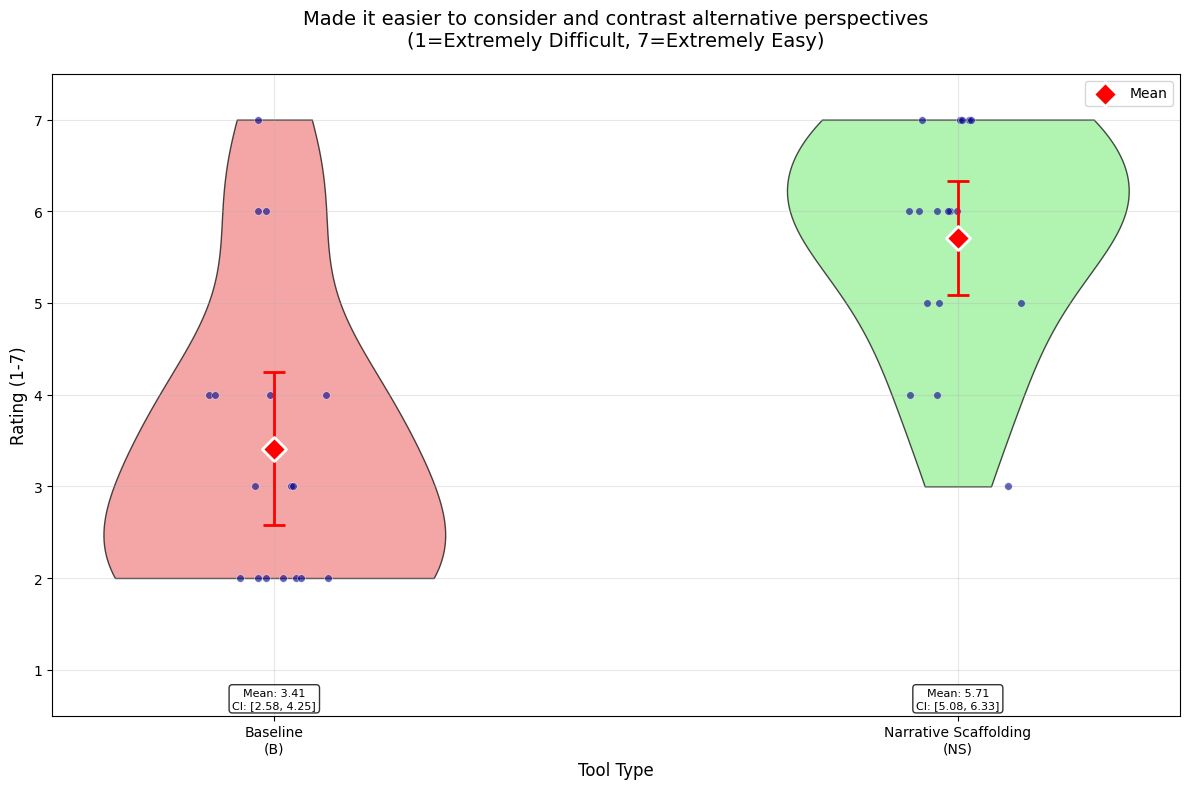


Comparison Summary with 95% Confidence Intervals:
Baseline Tool (B-11) Mean: 3.41, CI: [2.58, 4.25]
Narrative Scaffolding (NS-11) Mean: 5.71, CI: [5.08, 6.33]
Difference (NS-11 - B-11): 2.29


In [25]:
# Create violin plot comparison for B-11/NS-11
plt.figure(figsize=(12, 8))

# Prepare data for violin plot
baseline_data_b11 = b11_scores.dropna()
novel_data_b11 = ns11_scores.dropna()

# Create combined dataset for violin plot
all_data_b11 = [baseline_data_b11, novel_data_b11]
positions = [1, 2]

# Create violin plot
violin_parts_b11 = plt.violinplot(all_data_b11, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching style)
colors = ['lightcoral', 'lightgreen']
for pc, color in zip(violin_parts_b11['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter
np.random.seed(42)  # For reproducible jitter
for j, (dataset, pos) in enumerate(zip(all_data_b11, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, len(dataset))
    plt.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean_b11 = baseline_data_b11.mean()
novel_mean_b11 = novel_data_b11.mean()

# 95% confidence intervals
baseline_ci_b11 = stats.t.interval(0.95, len(baseline_data_b11)-1, loc=baseline_mean_b11, scale=stats.sem(baseline_data_b11))
novel_ci_b11 = stats.t.interval(0.95, len(novel_data_b11)-1, loc=novel_mean_b11, scale=stats.sem(novel_data_b11))

# Add mean markers
plt.scatter([1], [baseline_mean_b11], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
plt.scatter([2], [novel_mean_b11], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
plt.errorbar([1], [baseline_mean_b11], yerr=[[baseline_mean_b11 - baseline_ci_b11[0]], [baseline_ci_b11[1] - baseline_mean_b11]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
plt.errorbar([2], [novel_mean_b11], yerr=[[novel_mean_b11 - novel_ci_b11[0]], [novel_ci_b11[1] - novel_mean_b11]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot
plt.xticks([1, 2], ['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
plt.title('Made it easier to consider and contrast alternative perspectives\n(1=Extremely Difficult, 7=Extremely Easy)', fontsize=14, pad=20)
plt.ylabel('Rating (1-7)', fontsize=12)
plt.xlabel('Tool Type', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 7.5)

# Add text annotations for means and CIs
plt.text(1, 0.8, f'Mean: {baseline_mean_b11:.2f}\nCI: [{baseline_ci_b11[0]:.2f}, {baseline_ci_b11[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(2, 0.8, f'Mean: {novel_mean_b11:.2f}\nCI: [{novel_ci_b11[0]:.2f}, {novel_ci_b11[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print comparison with confidence intervals
print(f"\nComparison Summary with 95% Confidence Intervals:")
print(f"Baseline Tool (B-11) Mean: {baseline_mean_b11:.2f}, CI: [{baseline_ci_b11[0]:.2f}, {baseline_ci_b11[1]:.2f}]")
print(f"Narrative Scaffolding (NS-11) Mean: {novel_mean_b11:.2f}, CI: [{novel_ci_b11[0]:.2f}, {novel_ci_b11[1]:.2f}]")
print(f"Difference (NS-11 - B-11): {novel_mean_b11 - baseline_mean_b11:.2f}")

In [26]:
# Statistical Tests for B-9/NS-9 and B-11/NS-11 Comparisons
print("\n" + "=" * 80)
print("STATISTICAL TESTS FOR ADDITIONAL USABILITY COMPARISONS")
print("=" * 80)

additional_results = {}

# Test 1: B-9_1 vs NS-9_1 (Encourages different ways of analyzing)
print("\n1. ENCOURAGES DIFFERENT WAYS OF ANALYZING DATA (B-9 vs NS-9)")
print("-" * 65)

baseline_b9 = b9_scores.dropna()
novel_b9 = ns9_scores.dropna()

# Paired t-test
t_stat_b9, p_value_b9 = stats.ttest_rel(baseline_b9, novel_b9)

# Effect size (Cohen's d for paired samples)
diff_scores_b9 = novel_b9 - baseline_b9
cohen_d_b9 = diff_scores_b9.mean() / diff_scores_b9.std()

# Wilcoxon signed-rank test
wilcoxon_stat_b9, wilcoxon_p_b9 = stats.wilcoxon(baseline_b9, novel_b9)

additional_results['9'] = {
    'question': 'Encourages Different Analysis Ways',
    'baseline_mean': baseline_b9.mean(),
    'novel_mean': novel_b9.mean(),
    'mean_diff': novel_b9.mean() - baseline_b9.mean(),
    't_stat': t_stat_b9,
    'p_value': p_value_b9,
    'cohen_d': cohen_d_b9,
    'wilcoxon_p': wilcoxon_p_b9
}

print(f"Paired t-test:")
print(f"  t-statistic: {t_stat_b9:.4f}")
print(f"  p-value: {p_value_b9:.6f}")
print(f"  Effect size (Cohen's d): {cohen_d_b9:.4f}")

print(f"Wilcoxon signed-rank test:")
print(f"  p-value: {wilcoxon_p_b9:.6f}")

# Test 2: B-11_1 vs NS-11_1 (Easier to reflect on perspectives)
print("\n\n2. EASIER TO REFLECT ON AND CONTRAST PERSPECTIVES (B-11 vs NS-11)")
print("-" * 65)

baseline_b11 = b11_scores.dropna()
novel_b11 = ns11_scores.dropna()

# Paired t-test
t_stat_b11, p_value_b11 = stats.ttest_rel(baseline_b11, novel_b11)

# Effect size (Cohen's d for paired samples)
diff_scores_b11 = novel_b11 - baseline_b11
cohen_d_b11 = diff_scores_b11.mean() / diff_scores_b11.std()

# Wilcoxon signed-rank test
wilcoxon_stat_b11, wilcoxon_p_b11 = stats.wilcoxon(baseline_b11, novel_b11)

additional_results['11'] = {
    'question': 'Reflect on Alternative Perspectives',
    'baseline_mean': baseline_b11.mean(),
    'novel_mean': novel_b11.mean(),
    'mean_diff': novel_b11.mean() - baseline_b11.mean(),
    't_stat': t_stat_b11,
    'p_value': p_value_b11,
    'cohen_d': cohen_d_b11,
    'wilcoxon_p': wilcoxon_p_b11
}

print(f"Paired t-test:")
print(f"  t-statistic: {t_stat_b11:.4f}")
print(f"  p-value: {p_value_b11:.6f}")
print(f"  Effect size (Cohen's d): {cohen_d_b11:.4f}")

print(f"Wilcoxon signed-rank test:")
print(f"  p-value: {wilcoxon_p_b11:.6f}")

# Summary table
print(f"\n\n" + "=" * 95)
print("ADDITIONAL USABILITY STATISTICAL SUMMARY")
print("=" * 95)
cohens_d_label = "Cohen's d"
print(f"{'Question':<35} {'B Mean':<8} {'NS Mean':<8} {'Diff':<8} {'p-value':<10} {cohens_d_label:<10} {'Sig':<5} {'Winner':<10}")
print("-" * 95)

for q_num, results in additional_results.items():
    significance = "***" if results['p_value'] < 0.001 else "**" if results['p_value'] < 0.01 else "*" if results['p_value'] < 0.05 else "ns"
    
    # Determine winner (higher is better for these usability questions)
    if results['novel_mean'] > results['baseline_mean']:
        winner = "Novel" if results['p_value'] < 0.05 else "Novel (ns)"
    elif results['novel_mean'] < results['baseline_mean']:
        winner = "Baseline" if results['p_value'] < 0.05 else "Base (ns)"
    else:
        winner = "Tie"
    
    print(f"{results['question']:<35} {results['baseline_mean']:<8.2f} {results['novel_mean']:<8.2f} "
          f"{results['mean_diff']:<+8.2f} {results['p_value']:<10.6f} {results['cohen_d']:<10.3f} {significance:<5} {winner:<10}")

print(f"\nInterpretation:")
print(f"• Higher scores = Better performance for these usability measures")
print(f"• Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print(f"• Winner column shows which system performs better (if significant)")

# Key findings
print(f"\nKey Additional Usability Findings:")
significant_results_additional = []
for q_num, results in additional_results.items():
    question = results['question']
    diff = results['mean_diff']
    p_val = results['p_value']
    
    if p_val < 0.05:
        if diff > 0:  # Narrative Scaffolding has higher scores = better
            interpretation = "Narrative Scaffolding BETTER"
            significant_results_additional.append(f"✓ {question}: {interpretation} (diff: +{diff:.2f}, p: {p_val:.3f})")
        else:  # Narrative Scaffolding has lower scores = worse
            interpretation = "Baseline Tool BETTER"
            significant_results_additional.append(f"✗ {question}: {interpretation} (diff: {diff:.2f}, p: {p_val:.3f})")
    else:
        significant_results_additional.append(f"≈ {question}: No significant difference (diff: {diff:+.2f}, p: {p_val:.3f})")

for result in significant_results_additional:
    print(result)


STATISTICAL TESTS FOR ADDITIONAL USABILITY COMPARISONS

1. ENCOURAGES DIFFERENT WAYS OF ANALYZING DATA (B-9 vs NS-9)
-----------------------------------------------------------------
Paired t-test:
  t-statistic: -4.1010
  p-value: 0.000835
  Effect size (Cohen's d): 0.9946
Wilcoxon signed-rank test:
  p-value: 0.002530


2. EASIER TO REFLECT ON AND CONTRAST PERSPECTIVES (B-11 vs NS-11)
-----------------------------------------------------------------
Paired t-test:
  t-statistic: -4.9038
  p-value: 0.000159
  Effect size (Cohen's d): 1.1894
Wilcoxon signed-rank test:
  p-value: 0.001587


ADDITIONAL USABILITY STATISTICAL SUMMARY
Question                            B Mean   NS Mean  Diff     p-value    Cohen's d  Sig   Winner    
-----------------------------------------------------------------------------------------------
Encourages Different Analysis Ways  4.24     6.18     +1.94    0.000835   0.995      ***   Novel     
Reflect on Alternative Perspectives 3.41     5.71     +2.29  

In [27]:
# Analysis for B-13_1 and NS-13_1: "Recognize when to revisit or revise earlier reasoning"
print("=" * 80)
print("ANALYSIS: RECOGNIZE WHEN TO REVISIT OR REVISE EARLIER REASONING (B-13 vs NS-13)")
print("=" * 80)

# Convert text responses to numeric values using the same Likert mapping
b13_scores = df['B-13_1'].map(likert_mapping)
ns13_scores = df['NS-13_1'].map(likert_mapping)

print("B-13_1 (Baseline Tool) - Recognize when to revisit/revise reasoning:")
print(f"Mean: {b13_scores.mean():.2f}")
print(f"Median: {b13_scores.median():.2f}")
print(f"Min: {b13_scores.min()}, Max: {b13_scores.max()}")
print(f"Valid responses: {b13_scores.count()}")

print("\nNS-13_1 (Narrative Scaffolding) - Recognize when to revisit/revise reasoning:")
print(f"Mean: {ns13_scores.mean():.2f}")
print(f"Median: {ns13_scores.median():.2f}")
print(f"Min: {ns13_scores.min()}, Max: {ns13_scores.max()}")
print(f"Valid responses: {ns13_scores.count()}")

print("\nResponse distribution:")
print("B-13_1:", dict(b13_scores.value_counts().sort_index()))
print("NS-13_1:", dict(ns13_scores.value_counts().sort_index()))

ANALYSIS: RECOGNIZE WHEN TO REVISIT OR REVISE EARLIER REASONING (B-13 vs NS-13)
B-13_1 (Baseline Tool) - Recognize when to revisit/revise reasoning:
Mean: 3.18
Median: 3.00
Min: 1, Max: 7
Valid responses: 17

NS-13_1 (Narrative Scaffolding) - Recognize when to revisit/revise reasoning:
Mean: 5.76
Median: 6.00
Min: 3, Max: 7
Valid responses: 17

Response distribution:
B-13_1: {1: 1, 2: 5, 3: 6, 4: 2, 5: 2, 7: 1}
NS-13_1: {3: 2, 5: 4, 6: 5, 7: 6}


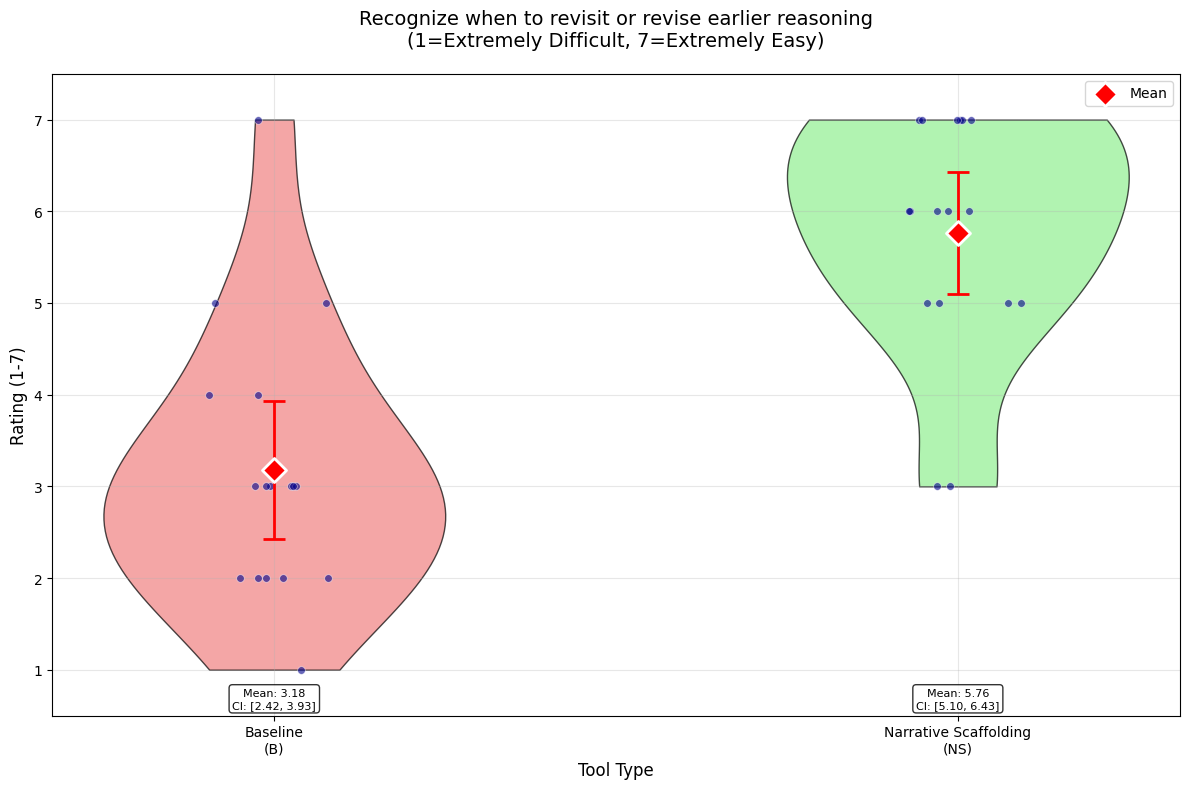


Comparison Summary with 95% Confidence Intervals:
Baseline Tool (B-13) Mean: 3.18, CI: [2.42, 3.93]
Narrative Scaffolding (NS-13) Mean: 5.76, CI: [5.10, 6.43]
Difference (NS-13 - B-13): 2.59


In [28]:
# Create violin plot comparison for B-13/NS-13
plt.figure(figsize=(12, 8))

# Prepare data for violin plot
baseline_data_b13 = b13_scores.dropna()
novel_data_b13 = ns13_scores.dropna()

# Create combined dataset for violin plot
all_data_b13 = [baseline_data_b13, novel_data_b13]
positions = [1, 2]

# Create violin plot
violin_parts_b13 = plt.violinplot(all_data_b13, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching style)
colors = ['lightcoral', 'lightgreen']
for pc, color in zip(violin_parts_b13['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter
np.random.seed(42)  # For reproducible jitter
for j, (dataset, pos) in enumerate(zip(all_data_b13, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, len(dataset))
    plt.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean_b13 = baseline_data_b13.mean()
novel_mean_b13 = novel_data_b13.mean()

# 95% confidence intervals
baseline_ci_b13 = stats.t.interval(0.95, len(baseline_data_b13)-1, loc=baseline_mean_b13, scale=stats.sem(baseline_data_b13))
novel_ci_b13 = stats.t.interval(0.95, len(novel_data_b13)-1, loc=novel_mean_b13, scale=stats.sem(novel_data_b13))

# Add mean markers
plt.scatter([1], [baseline_mean_b13], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
plt.scatter([2], [novel_mean_b13], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
plt.errorbar([1], [baseline_mean_b13], yerr=[[baseline_mean_b13 - baseline_ci_b13[0]], [baseline_ci_b13[1] - baseline_mean_b13]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
plt.errorbar([2], [novel_mean_b13], yerr=[[novel_mean_b13 - novel_ci_b13[0]], [novel_ci_b13[1] - novel_mean_b13]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot
plt.xticks([1, 2], ['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
plt.title('Recognize when to revisit or revise earlier reasoning\n(1=Extremely Difficult, 7=Extremely Easy)', fontsize=14, pad=20)
plt.ylabel('Rating (1-7)', fontsize=12)
plt.xlabel('Tool Type', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 7.5)

# Add text annotations for means and CIs
plt.text(1, 0.8, f'Mean: {baseline_mean_b13:.2f}\nCI: [{baseline_ci_b13[0]:.2f}, {baseline_ci_b13[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(2, 0.8, f'Mean: {novel_mean_b13:.2f}\nCI: [{novel_ci_b13[0]:.2f}, {novel_ci_b13[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print comparison with confidence intervals
print(f"\nComparison Summary with 95% Confidence Intervals:")
print(f"Baseline Tool (B-13) Mean: {baseline_mean_b13:.2f}, CI: [{baseline_ci_b13[0]:.2f}, {baseline_ci_b13[1]:.2f}]")
print(f"Narrative Scaffolding (NS-13) Mean: {novel_mean_b13:.2f}, CI: [{novel_ci_b13[0]:.2f}, {novel_ci_b13[1]:.2f}]")
print(f"Difference (NS-13 - B-13): {novel_mean_b13 - baseline_mean_b13:.2f}")

In [29]:
# Analysis for B-15_1 and NS-15_1: "Support reflecting on trade-offs between different options"
print("=" * 80)
print("ANALYSIS: SUPPORT REFLECTING ON TRADE-OFFS BETWEEN DIFFERENT OPTIONS (B-15 vs NS-15)")
print("=" * 80)

# Convert text responses to numeric values using the same Likert mapping
b15_scores = df['B-15_1'].map(likert_mapping)
ns15_scores = df['NS-15_1'].map(likert_mapping)

print("B-15_1 (Baseline Tool) - Support reflecting on trade-offs:")
print(f"Mean: {b15_scores.mean():.2f}")
print(f"Median: {b15_scores.median():.2f}")
print(f"Min: {b15_scores.min()}, Max: {b15_scores.max()}")
print(f"Valid responses: {b15_scores.count()}")

print("\nNS-15_1 (Narrative Scaffolding) - Support reflecting on trade-offs:")
print(f"Mean: {ns15_scores.mean():.2f}")
print(f"Median: {ns15_scores.median():.2f}")
print(f"Min: {ns15_scores.min()}, Max: {ns15_scores.max()}")
print(f"Valid responses: {ns15_scores.count()}")

print("\nResponse distribution:")
print("B-15_1:", dict(b15_scores.value_counts().sort_index()))
print("NS-15_1:", dict(ns15_scores.value_counts().sort_index()))

ANALYSIS: SUPPORT REFLECTING ON TRADE-OFFS BETWEEN DIFFERENT OPTIONS (B-15 vs NS-15)
B-15_1 (Baseline Tool) - Support reflecting on trade-offs:
Mean: 3.82
Median: 3.00
Min: 1, Max: 7
Valid responses: 17

NS-15_1 (Narrative Scaffolding) - Support reflecting on trade-offs:
Mean: 5.65
Median: 6.00
Min: 3, Max: 7
Valid responses: 17

Response distribution:
B-15_1: {1: 1, 2: 1, 3: 7, 4: 2, 5: 4, 6: 1, 7: 1}
NS-15_1: {3: 2, 4: 2, 5: 2, 6: 5, 7: 6}


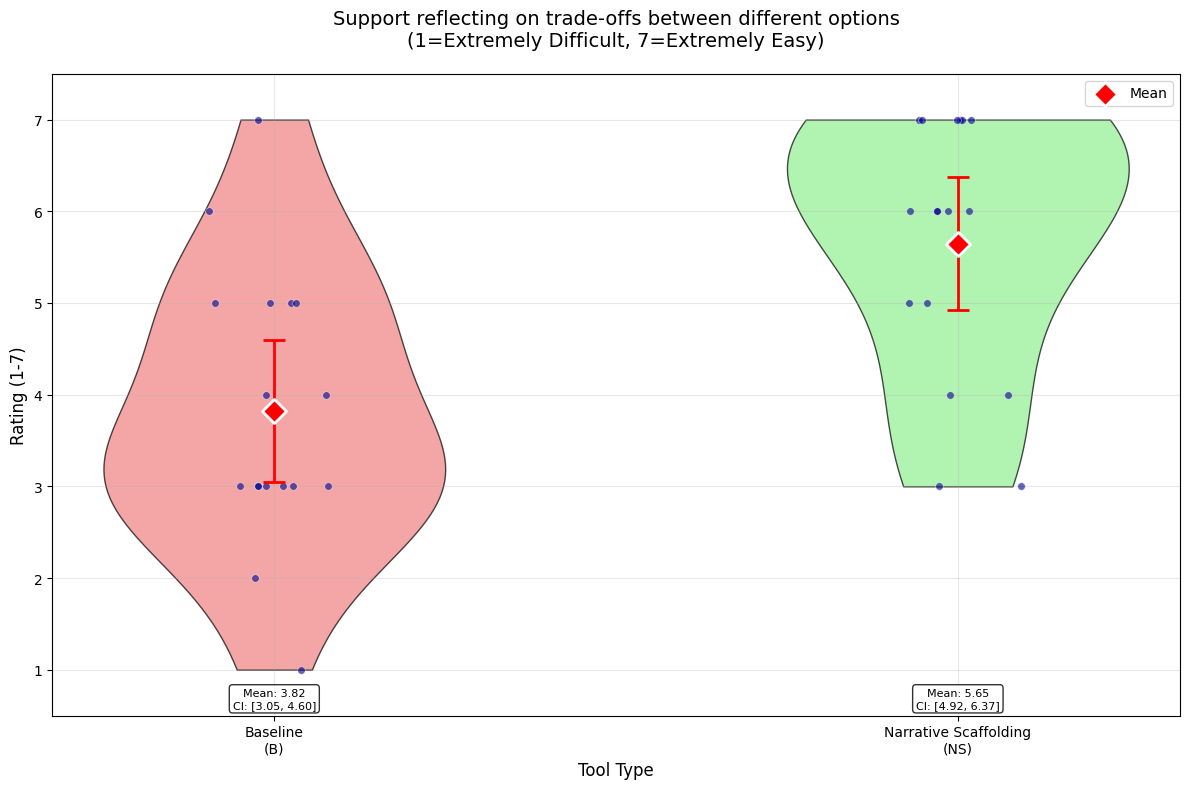


Comparison Summary with 95% Confidence Intervals:
Baseline Tool (B-15) Mean: 3.82, CI: [3.05, 4.60]
Narrative Scaffolding (NS-15) Mean: 5.65, CI: [4.92, 6.37]
Difference (NS-15 - B-15): 1.82


In [30]:
# Create violin plot comparison for B-15/NS-15
plt.figure(figsize=(12, 8))

# Prepare data for violin plot
baseline_data_b15 = b15_scores.dropna()
novel_data_b15 = ns15_scores.dropna()

# Create combined dataset for violin plot
all_data_b15 = [baseline_data_b15, novel_data_b15]
positions = [1, 2]

# Create violin plot
violin_parts_b15 = plt.violinplot(all_data_b15, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching style)
colors = ['lightcoral', 'lightgreen']
for pc, color in zip(violin_parts_b15['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter
np.random.seed(42)  # For reproducible jitter
for j, (dataset, pos) in enumerate(zip(all_data_b15, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, len(dataset))
    plt.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean_b15 = baseline_data_b15.mean()
novel_mean_b15 = novel_data_b15.mean()

# 95% confidence intervals
baseline_ci_b15 = stats.t.interval(0.95, len(baseline_data_b15)-1, loc=baseline_mean_b15, scale=stats.sem(baseline_data_b15))
novel_ci_b15 = stats.t.interval(0.95, len(novel_data_b15)-1, loc=novel_mean_b15, scale=stats.sem(novel_data_b15))

# Add mean markers
plt.scatter([1], [baseline_mean_b15], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
plt.scatter([2], [novel_mean_b15], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
plt.errorbar([1], [baseline_mean_b15], yerr=[[baseline_mean_b15 - baseline_ci_b15[0]], [baseline_ci_b15[1] - baseline_mean_b15]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
plt.errorbar([2], [novel_mean_b15], yerr=[[novel_mean_b15 - novel_ci_b15[0]], [novel_ci_b15[1] - novel_mean_b15]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot
plt.xticks([1, 2], ['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
plt.title('Support reflecting on trade-offs between different options\n(1=Extremely Difficult, 7=Extremely Easy)', fontsize=14, pad=20)
plt.ylabel('Rating (1-7)', fontsize=12)
plt.xlabel('Tool Type', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 7.5)

# Add text annotations for means and CIs
plt.text(1, 0.8, f'Mean: {baseline_mean_b15:.2f}\nCI: [{baseline_ci_b15[0]:.2f}, {baseline_ci_b15[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(2, 0.8, f'Mean: {novel_mean_b15:.2f}\nCI: [{novel_ci_b15[0]:.2f}, {novel_ci_b15[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print comparison with confidence intervals
print(f"\nComparison Summary with 95% Confidence Intervals:")
print(f"Baseline Tool (B-15) Mean: {baseline_mean_b15:.2f}, CI: [{baseline_ci_b15[0]:.2f}, {baseline_ci_b15[1]:.2f}]")
print(f"Narrative Scaffolding (NS-15) Mean: {novel_mean_b15:.2f}, CI: [{novel_ci_b15[0]:.2f}, {novel_ci_b15[1]:.2f}]")
print(f"Difference (NS-15 - B-15): {novel_mean_b15 - baseline_mean_b15:.2f}")

In [31]:
# Statistical Tests for B-13/NS-13 and B-15/NS-15 Comparisons
print("\n" + "=" * 80)
print("STATISTICAL TESTS FOR REASONING & TRADE-OFF REFLECTION COMPARISONS")
print("=" * 80)

reasoning_results = {}

# Test 1: B-13_1 vs NS-13_1 (Recognize when to revisit/revise reasoning)
print("\n1. RECOGNIZE WHEN TO REVISIT OR REVISE EARLIER REASONING (B-13 vs NS-13)")
print("-" * 70)

baseline_b13 = b13_scores.dropna()
novel_b13 = ns13_scores.dropna()

# Paired t-test
t_stat_b13, p_value_b13 = stats.ttest_rel(baseline_b13, novel_b13)

# Effect size (Cohen's d for paired samples)
diff_scores_b13 = novel_b13 - baseline_b13
cohen_d_b13 = diff_scores_b13.mean() / diff_scores_b13.std()

# Wilcoxon signed-rank test
wilcoxon_stat_b13, wilcoxon_p_b13 = stats.wilcoxon(baseline_b13, novel_b13)

reasoning_results['13'] = {
    'question': 'Revisit/Revise Earlier Reasoning',
    'baseline_mean': baseline_b13.mean(),
    'novel_mean': novel_b13.mean(),
    'mean_diff': novel_b13.mean() - baseline_b13.mean(),
    't_stat': t_stat_b13,
    'p_value': p_value_b13,
    'cohen_d': cohen_d_b13,
    'wilcoxon_p': wilcoxon_p_b13
}

print(f"Paired t-test:")
print(f"  t-statistic: {t_stat_b13:.4f}")
print(f"  p-value: {p_value_b13:.6f}")
print(f"  Effect size (Cohen's d): {cohen_d_b13:.4f}")

print(f"Wilcoxon signed-rank test:")
print(f"  p-value: {wilcoxon_p_b13:.6f}")

# Test 2: B-15_1 vs NS-15_1 (Support reflecting on trade-offs)
print("\n\n2. SUPPORT REFLECTING ON TRADE-OFFS BETWEEN OPTIONS (B-15 vs NS-15)")
print("-" * 70)

baseline_b15 = b15_scores.dropna()
novel_b15 = ns15_scores.dropna()

# Paired t-test
t_stat_b15, p_value_b15 = stats.ttest_rel(baseline_b15, novel_b15)

# Effect size (Cohen's d for paired samples)
diff_scores_b15 = novel_b15 - baseline_b15
cohen_d_b15 = diff_scores_b15.mean() / diff_scores_b15.std()

# Wilcoxon signed-rank test
wilcoxon_stat_b15, wilcoxon_p_b15 = stats.wilcoxon(baseline_b15, novel_b15)

reasoning_results['15'] = {
    'question': 'Reflect on Trade-offs',
    'baseline_mean': baseline_b15.mean(),
    'novel_mean': novel_b15.mean(),
    'mean_diff': novel_b15.mean() - baseline_b15.mean(),
    't_stat': t_stat_b15,
    'p_value': p_value_b15,
    'cohen_d': cohen_d_b15,
    'wilcoxon_p': wilcoxon_p_b15
}

print(f"Paired t-test:")
print(f"  t-statistic: {t_stat_b15:.4f}")
print(f"  p-value: {p_value_b15:.6f}")
print(f"  Effect size (Cohen's d): {cohen_d_b15:.4f}")

print(f"Wilcoxon signed-rank test:")
print(f"  p-value: {wilcoxon_p_b15:.6f}")

# Summary table
print(f"\n\n" + "=" * 95)
print("REASONING & TRADE-OFF REFLECTION STATISTICAL SUMMARY")
print("=" * 95)
cohens_d_label = "Cohen's d"
print(f"{'Question':<35} {'B Mean':<8} {'NS Mean':<8} {'Diff':<8} {'p-value':<10} {cohens_d_label:<10} {'Sig':<5} {'Winner':<10}")
print("-" * 95)

for q_num, results in reasoning_results.items():
    significance = "***" if results['p_value'] < 0.001 else "**" if results['p_value'] < 0.01 else "*" if results['p_value'] < 0.05 else "ns"
    
    # Determine winner (higher is better for these usability questions)
    if results['novel_mean'] > results['baseline_mean']:
        winner = "Novel" if results['p_value'] < 0.05 else "Novel (ns)"
    elif results['novel_mean'] < results['baseline_mean']:
        winner = "Baseline" if results['p_value'] < 0.05 else "Base (ns)"
    else:
        winner = "Tie"
    
    print(f"{results['question']:<35} {results['baseline_mean']:<8.2f} {results['novel_mean']:<8.2f} "
          f"{results['mean_diff']:<+8.2f} {results['p_value']:<10.6f} {results['cohen_d']:<10.3f} {significance:<5} {winner:<10}")

print(f"\nInterpretation:")
print(f"• Higher scores = Better performance for reasoning and reflection measures")
print(f"• Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print(f"• Winner column shows which system performs better (if significant)")

# Key findings
print(f"\nKey Reasoning & Trade-off Reflection Findings:")
significant_results_reasoning = []
for q_num, results in reasoning_results.items():
    question = results['question']
    diff = results['mean_diff']
    p_val = results['p_value']
    
    if p_val < 0.05:
        if diff > 0:  # Narrative Scaffolding has higher scores = better
            interpretation = "Narrative Scaffolding BETTER"
            significant_results_reasoning.append(f"✓ {question}: {interpretation} (diff: +{diff:.2f}, p: {p_val:.3f})")
        else:  # Narrative Scaffolding has lower scores = worse
            interpretation = "Baseline Tool BETTER"
            significant_results_reasoning.append(f"✗ {question}: {interpretation} (diff: {diff:.2f}, p: {p_val:.3f})")
    else:
        significant_results_reasoning.append(f"≈ {question}: No significant difference (diff: {diff:+.2f}, p: {p_val:.3f})")

for result in significant_results_reasoning:
    print(result)


STATISTICAL TESTS FOR REASONING & TRADE-OFF REFLECTION COMPARISONS

1. RECOGNIZE WHEN TO REVISIT OR REVISE EARLIER REASONING (B-13 vs NS-13)
----------------------------------------------------------------------
Paired t-test:
  t-statistic: -5.3309
  p-value: 0.000068
  Effect size (Cohen's d): 1.2929
Wilcoxon signed-rank test:
  p-value: 0.001641


2. SUPPORT REFLECTING ON TRADE-OFFS BETWEEN OPTIONS (B-15 vs NS-15)
----------------------------------------------------------------------
Paired t-test:
  t-statistic: -3.7456
  p-value: 0.001764
  Effect size (Cohen's d): 0.9084
Wilcoxon signed-rank test:
  p-value: 0.005733


REASONING & TRADE-OFF REFLECTION STATISTICAL SUMMARY
Question                            B Mean   NS Mean  Diff     p-value    Cohen's d  Sig   Winner    
-----------------------------------------------------------------------------------------------
Revisit/Revise Earlier Reasoning    3.18     5.76     +2.59    0.000068   1.293      ***   Novel     
Reflect on Tr

In [32]:
# Analysis for B-17_1 vs NS-17_1: defend reasoning behind the insights generated
print("=== Comparison B-17_1 vs NS-17_1: Defend reasoning behind insights ===")

# Define mapping for ease/difficulty scale (1 = Extremely difficult, 7 = Extremely easy)
ease_mapping = {
    'Extremely difficult': 1,
    'Moderately difficult': 2,
    'Slightly difficult': 3,
    'Neither easy nor difficult': 4,
    'Slightly easy': 5,
    'Moderately easy': 6,
    'Extremely easy': 7
}

# Extract and convert scores for B-17_1 and NS-17_1
b17_raw = df['B-17_1'].dropna()
ns17_raw = df['NS-17_1'].dropna()

# Map text responses to numeric values
b17_scores = b17_raw.map(ease_mapping)
ns17_scores = ns17_raw.map(ease_mapping)

print(f"Valid responses - Baseline (B-17): {len(b17_scores)}, Narrative Scaffolding (NS-17): {len(ns17_scores)}")
print(f"Baseline B-17 scores: mean={b17_scores.mean():.2f}, std={b17_scores.std():.2f}")
print(f"Narrative Scaffolding NS-17 scores: mean={ns17_scores.mean():.2f}, std={ns17_scores.std():.2f}")

# Check for any unmapped values
if b17_scores.isnull().any() or ns17_scores.isnull().any():
    print("Warning: Some values could not be mapped!")
    print(f"B-17 unique values: {b17_raw.unique()}")
    print(f"NS-17 unique values: {ns17_raw.unique()}")

# Perform paired t-test (assuming paired data)
if len(b17_scores) == len(ns17_scores):
    diff_scores_b17 = ns17_scores.reset_index(drop=True) - b17_scores.reset_index(drop=True)
    
    # Paired t-test
    t_stat_b17, p_value_b17 = stats.ttest_rel(ns17_scores, b17_scores)
    
    # Wilcoxon signed-rank test (non-parametric alternative)
    wilcoxon_stat_b17, wilcoxon_p_b17 = stats.wilcoxon(ns17_scores, b17_scores)
    
    # Calculate Cohen's d for effect size
    pooled_std = np.sqrt(((len(b17_scores)-1)*b17_scores.std()**2 + (len(ns17_scores)-1)*ns17_scores.std()**2) / (len(b17_scores)+len(ns17_scores)-2))
    cohen_d_b17 = (ns17_scores.mean() - b17_scores.mean()) / pooled_std
    
    print(f"\nPaired t-test: t-statistic = {t_stat_b17:.4f}, p-value = {p_value_b17:.4f}")
    print(f"Wilcoxon signed-rank test: statistic = {wilcoxon_stat_b17:.4f}, p-value = {wilcoxon_p_b17:.4f}")
    print(f"Cohen's d (effect size): {cohen_d_b17:.4f}")
    
    # Effect size interpretation
    if abs(cohen_d_b17) < 0.2:
        effect_size_label = "negligible"
    elif abs(cohen_d_b17) < 0.5:
        effect_size_label = "small" 
    elif abs(cohen_d_b17) < 0.8:
        effect_size_label = "medium"
    else:
        effect_size_label = "large"
    
    significance = "significant" if p_value_b17 < 0.05 else "not significant"
    improvement = f"{ns17_scores.mean() - b17_scores.mean():+.2f}"
    
    print(f"Difference: {improvement} points (Narrative Scaffolding - Baseline)")
    print(f"Statistical significance: {significance} (α = 0.05)")
    print(f"Effect size: {effect_size_label}")
    
else:
    print("Unequal sample sizes - using independent samples t-test")
    t_stat_b17, p_value_b17 = stats.ttest_ind(ns17_scores, b17_scores)
    print(f"Independent t-test: t-statistic = {t_stat_b17:.4f}, p-value = {p_value_b17:.4f}")

=== Comparison B-17_1 vs NS-17_1: Defend reasoning behind insights ===
Valid responses - Baseline (B-17): 17, Narrative Scaffolding (NS-17): 17
Baseline B-17 scores: mean=3.41, std=1.80
Narrative Scaffolding NS-17 scores: mean=5.88, std=1.32

Paired t-test: t-statistic = 4.3377, p-value = 0.0005
Wilcoxon signed-rank test: statistic = 14.0000, p-value = 0.0017
Cohen's d (effect size): 1.5637
Difference: +2.47 points (Narrative Scaffolding - Baseline)
Statistical significance: significant (α = 0.05)
Effect size: large


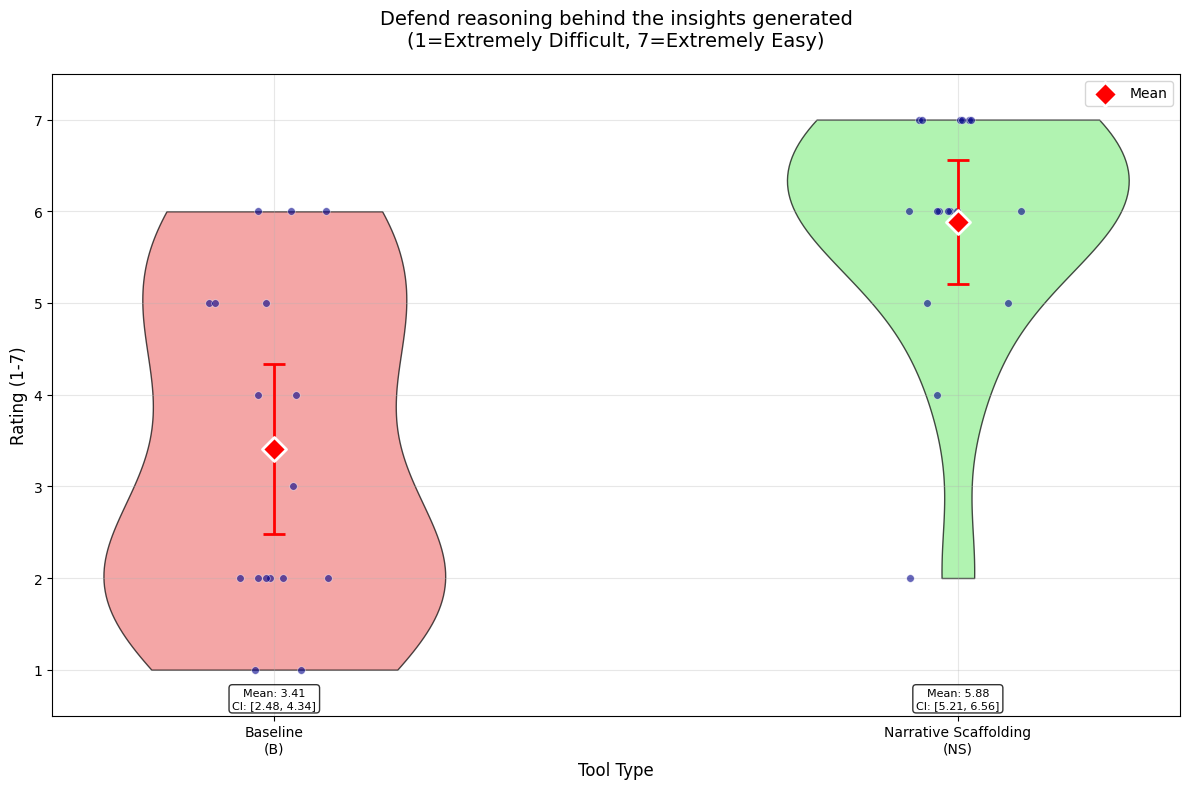


Comparison Summary with 95% Confidence Intervals:
Baseline Tool (B-17) Mean: 3.41, CI: [2.48, 4.34]
Narrative Scaffolding (NS-17) Mean: 5.88, CI: [5.21, 6.56]
Difference (NS-17 - B-17): 2.47


In [33]:
# Create violin plot comparison for B-17/NS-17
plt.figure(figsize=(12, 8))

# Prepare data for violin plot
baseline_data_b17 = b17_scores.dropna()
novel_data_b17 = ns17_scores.dropna()

# Create combined dataset for violin plot
all_data_b17 = [baseline_data_b17, novel_data_b17]
positions = [1, 2]

# Create violin plot
violin_parts_b17 = plt.violinplot(all_data_b17, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching style)
colors = ['lightcoral', 'lightgreen']
for pc, color in zip(violin_parts_b17['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter
np.random.seed(42)  # For reproducible jitter
for j, (dataset, pos) in enumerate(zip(all_data_b17, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, len(dataset))
    plt.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean_b17 = baseline_data_b17.mean()
novel_mean_b17 = novel_data_b17.mean()

# 95% confidence intervals
baseline_ci_b17 = stats.t.interval(0.95, len(baseline_data_b17)-1, loc=baseline_mean_b17, scale=stats.sem(baseline_data_b17))
novel_ci_b17 = stats.t.interval(0.95, len(novel_data_b17)-1, loc=novel_mean_b17, scale=stats.sem(novel_data_b17))

# Add mean markers
plt.scatter([1], [baseline_mean_b17], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
plt.scatter([2], [novel_mean_b17], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
plt.errorbar([1], [baseline_mean_b17], yerr=[[baseline_mean_b17 - baseline_ci_b17[0]], [baseline_ci_b17[1] - baseline_mean_b17]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
plt.errorbar([2], [novel_mean_b17], yerr=[[novel_mean_b17 - novel_ci_b17[0]], [novel_ci_b17[1] - novel_mean_b17]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot
plt.xticks([1, 2], ['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
plt.title('Defend reasoning behind the insights generated\n(1=Extremely Difficult, 7=Extremely Easy)', fontsize=14, pad=20)
plt.ylabel('Rating (1-7)', fontsize=12)
plt.xlabel('Tool Type', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 7.5)

# Add text annotations for means and CIs
plt.text(1, 0.8, f'Mean: {baseline_mean_b17:.2f}\nCI: [{baseline_ci_b17[0]:.2f}, {baseline_ci_b17[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(2, 0.8, f'Mean: {novel_mean_b17:.2f}\nCI: [{novel_ci_b17[0]:.2f}, {novel_ci_b17[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print comparison with confidence intervals
print(f"\nComparison Summary with 95% Confidence Intervals:")
print(f"Baseline Tool (B-17) Mean: {baseline_mean_b17:.2f}, CI: [{baseline_ci_b17[0]:.2f}, {baseline_ci_b17[1]:.2f}]")
print(f"Narrative Scaffolding (NS-17) Mean: {novel_mean_b17:.2f}, CI: [{novel_ci_b17[0]:.2f}, {novel_ci_b17[1]:.2f}]")
print(f"Difference (NS-17 - B-17): {novel_mean_b17 - baseline_mean_b17:.2f}")

In [34]:
# Analysis for B-19_1 vs NS-19_1: confident to presenting your conclusions to others
print("=== Comparison B-19_1 vs NS-19_1: Confident presenting conclusions to others ===")

# Define mapping for confidence scale (1 = Extremely unconfident, 7 = Extremely confident)
# Note: Original was comfort scale, but we're interpreting as confidence
confidence_mapping = {
    'Extremely uncomfortable': 1,
    'Moderately uncomfortable': 2,
    'Slightly uncomfortable': 3,
    'Neither comfortable nor uncomfortable': 4,
    'Slightly comfortable': 5,
    'Moderately comfortable': 6,
    'Extremely comfortable': 7
}

# Extract and convert scores for B-19_1 and NS-19_1
b19_raw = df['B-19_1'].dropna()
ns19_raw = df['NS-19_1'].dropna()

# Map text responses to numeric values
b19_scores = b19_raw.map(confidence_mapping)
ns19_scores = ns19_raw.map(confidence_mapping)

print(f"Valid responses - Baseline (B-19): {len(b19_scores)}, Narrative Scaffolding (NS-19): {len(ns19_scores)}")
print(f"Baseline B-19 scores: mean={b19_scores.mean():.2f}, std={b19_scores.std():.2f}")
print(f"Narrative Scaffolding NS-19 scores: mean={ns19_scores.mean():.2f}, std={ns19_scores.std():.2f}")

# Check for any unmapped values
if b19_scores.isnull().any() or ns19_scores.isnull().any():
    print("Warning: Some values could not be mapped!")
    print(f"B-19 unique values: {b19_raw.unique()}")
    print(f"NS-19 unique values: {ns19_raw.unique()}")

# Perform paired t-test (assuming paired data)
if len(b19_scores) == len(ns19_scores):
    diff_scores_b19 = ns19_scores.reset_index(drop=True) - b19_scores.reset_index(drop=True)
    
    # Paired t-test
    t_stat_b19, p_value_b19 = stats.ttest_rel(ns19_scores, b19_scores)
    
    # Wilcoxon signed-rank test (non-parametric alternative)
    wilcoxon_stat_b19, wilcoxon_p_b19 = stats.wilcoxon(ns19_scores, b19_scores)
    
    # Calculate Cohen's d for effect size
    pooled_std = np.sqrt(((len(b19_scores)-1)*b19_scores.std()**2 + (len(ns19_scores)-1)*ns19_scores.std()**2) / (len(b19_scores)+len(ns19_scores)-2))
    cohen_d_b19 = (ns19_scores.mean() - b19_scores.mean()) / pooled_std
    
    print(f"\nPaired t-test: t-statistic = {t_stat_b19:.4f}, p-value = {p_value_b19:.4f}")
    print(f"Wilcoxon signed-rank test: statistic = {wilcoxon_stat_b19:.4f}, p-value = {wilcoxon_p_b19:.4f}")
    print(f"Cohen's d (effect size): {cohen_d_b19:.4f}")
    
    # Effect size interpretation
    if abs(cohen_d_b19) < 0.2:
        effect_size_label_b19 = "negligible"
    elif abs(cohen_d_b19) < 0.5:
        effect_size_label_b19 = "small" 
    elif abs(cohen_d_b19) < 0.8:
        effect_size_label_b19 = "medium"
    else:
        effect_size_label_b19 = "large"
    
    significance_b19 = "significant" if p_value_b19 < 0.05 else "not significant"
    improvement_b19 = f"{ns19_scores.mean() - b19_scores.mean():+.2f}"
    
    print(f"Difference: {improvement_b19} points (Narrative Scaffolding - Baseline)")
    print(f"Statistical significance: {significance_b19} (α = 0.05)")
    print(f"Effect size: {effect_size_label_b19}")
    
else:
    print("Unequal sample sizes - using independent samples t-test")
    t_stat_b19, p_value_b19 = stats.ttest_ind(ns19_scores, b19_scores)
    print(f"Independent t-test: t-statistic = {t_stat_b19:.4f}, p-value = {p_value_b19:.4f}")

=== Comparison B-19_1 vs NS-19_1: Confident presenting conclusions to others ===
Valid responses - Baseline (B-19): 17, Narrative Scaffolding (NS-19): 17
Baseline B-19 scores: mean=5.06, std=1.68
Narrative Scaffolding NS-19 scores: mean=5.88, std=1.05

Paired t-test: t-statistic = 1.5332, p-value = 0.1448
Wilcoxon signed-rank test: statistic = 25.0000, p-value = 0.1481
Cohen's d (effect size): 0.5883
Difference: +0.82 points (Narrative Scaffolding - Baseline)
Statistical significance: not significant (α = 0.05)
Effect size: medium

Paired t-test: t-statistic = 1.5332, p-value = 0.1448
Wilcoxon signed-rank test: statistic = 25.0000, p-value = 0.1481
Cohen's d (effect size): 0.5883
Difference: +0.82 points (Narrative Scaffolding - Baseline)
Statistical significance: not significant (α = 0.05)
Effect size: medium


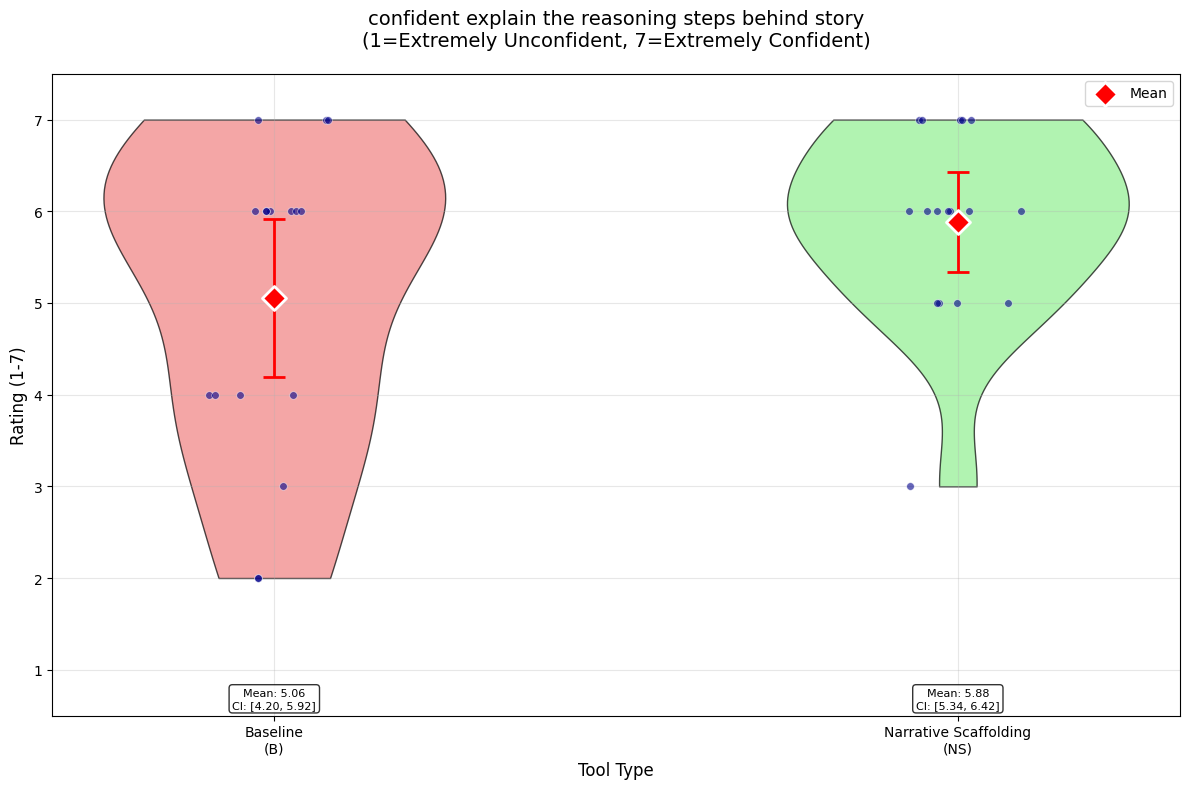


Comparison Summary with 95% Confidence Intervals:
Baseline Tool (B-19) Mean: 5.06, CI: [4.20, 5.92]
Narrative Scaffolding (NS-19) Mean: 5.88, CI: [5.34, 6.42]
Difference (NS-19 - B-19): 0.82


In [35]:
# Create violin plot comparison for B-19/NS-19
plt.figure(figsize=(12, 8))

# Prepare data for violin plot
baseline_data_b19 = b19_scores.dropna()
novel_data_b19 = ns19_scores.dropna()

# Create combined dataset for violin plot
all_data_b19 = [baseline_data_b19, novel_data_b19]
positions = [1, 2]

# Create violin plot
violin_parts_b19 = plt.violinplot(all_data_b19, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching style)
colors = ['lightcoral', 'lightgreen']
for pc, color in zip(violin_parts_b19['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter
np.random.seed(42)  # For reproducible jitter
for j, (dataset, pos) in enumerate(zip(all_data_b19, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, len(dataset))
    plt.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean_b19 = baseline_data_b19.mean()
novel_mean_b19 = novel_data_b19.mean()

# 95% confidence intervals
baseline_ci_b19 = stats.t.interval(0.95, len(baseline_data_b19)-1, loc=baseline_mean_b19, scale=stats.sem(baseline_data_b19))
novel_ci_b19 = stats.t.interval(0.95, len(novel_data_b19)-1, loc=novel_mean_b19, scale=stats.sem(novel_data_b19))

# Add mean markers
plt.scatter([1], [baseline_mean_b19], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
plt.scatter([2], [novel_mean_b19], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
plt.errorbar([1], [baseline_mean_b19], yerr=[[baseline_mean_b19 - baseline_ci_b19[0]], [baseline_ci_b19[1] - baseline_mean_b19]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
plt.errorbar([2], [novel_mean_b19], yerr=[[novel_mean_b19 - novel_ci_b19[0]], [novel_ci_b19[1] - novel_mean_b19]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot
plt.xticks([1, 2], ['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
plt.title('confident explain the reasoning steps behind story\n(1=Extremely Unconfident, 7=Extremely Confident)', fontsize=14, pad=20)
plt.ylabel('Rating (1-7)', fontsize=12)
plt.xlabel('Tool Type', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 7.5)

# Add text annotations for means and CIs
plt.text(1, 0.8, f'Mean: {baseline_mean_b19:.2f}\nCI: [{baseline_ci_b19[0]:.2f}, {baseline_ci_b19[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(2, 0.8, f'Mean: {novel_mean_b19:.2f}\nCI: [{novel_ci_b19[0]:.2f}, {novel_ci_b19[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print comparison with confidence intervals
print(f"\nComparison Summary with 95% Confidence Intervals:")
print(f"Baseline Tool (B-19) Mean: {baseline_mean_b19:.2f}, CI: [{baseline_ci_b19[0]:.2f}, {baseline_ci_b19[1]:.2f}]")
print(f"Narrative Scaffolding (NS-19) Mean: {novel_mean_b19:.2f}, CI: [{novel_ci_b19[0]:.2f}, {novel_ci_b19[1]:.2f}]")
print(f"Difference (NS-19 - B-19): {novel_mean_b19 - baseline_mean_b19:.2f}")

In [36]:
# Analysis for B-19_2 vs NS-19_2: exploration paths were meaningfully used in my final story or decision
print("=== Comparison B-19_2 vs NS-19_2: Exploration paths meaningfully used in final story ===")

# Define mapping for agreement scale (1 = Strongly Disagree, 7 = Strongly Agree)
# Based on the actual values found in the data
agreement_mapping = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Somewhat Disagree': 3,
    'Neither Agree nor Disagree': 4,
    'Somewhat Agree': 5,
    'Agree': 6,
    'Strongly Agree': 7
}

# Extract and convert scores for B-19_2 and NS-19_2
b19_2_raw = df['B-19_2'].dropna()
ns19_2_raw = df['NS-19_2'].dropna()

print("Raw data overview:")
print(f"B-19_2 values: {b19_2_raw.value_counts().to_dict()}")
print(f"NS-19_2 values: {ns19_2_raw.value_counts().to_dict()}")

# Map text responses to numeric values
b19_2_scores = b19_2_raw.map(agreement_mapping)
ns19_2_scores = ns19_2_raw.map(agreement_mapping)

print(f"\nValid responses - Baseline (B-19_2): {len(b19_2_scores)}, Narrative Scaffolding (NS-19_2): {len(ns19_2_scores)}")
print(f"Baseline B-19_2 scores: mean={b19_2_scores.mean():.2f}, std={b19_2_scores.std():.2f}")
print(f"Narrative Scaffolding NS-19_2 scores: mean={ns19_2_scores.mean():.2f}, std={ns19_2_scores.std():.2f}")

# Check for any unmapped values
if b19_2_scores.isnull().any() or ns19_2_scores.isnull().any():
    print("Warning: Some values could not be mapped!")
    print(f"B-19_2 unmapped values: {b19_2_raw[b19_2_scores.isnull()].unique()}")
    print(f"NS-19_2 unmapped values: {ns19_2_raw[ns19_2_scores.isnull()].unique()}")

# Perform paired t-test (assuming paired data)
if len(b19_2_scores) == len(ns19_2_scores):
    diff_scores_b19_2 = ns19_2_scores.reset_index(drop=True) - b19_2_scores.reset_index(drop=True)
    
    # Paired t-test
    t_stat_b19_2, p_value_b19_2 = stats.ttest_rel(ns19_2_scores, b19_2_scores)
    
    # Wilcoxon signed-rank test (non-parametric alternative)
    wilcoxon_stat_b19_2, wilcoxon_p_b19_2 = stats.wilcoxon(ns19_2_scores, b19_2_scores)
    
    # Calculate Cohen's d for effect size
    pooled_std = np.sqrt(((len(b19_2_scores)-1)*b19_2_scores.std()**2 + (len(ns19_2_scores)-1)*ns19_2_scores.std()**2) / (len(b19_2_scores)+len(ns19_2_scores)-2))
    cohen_d_b19_2 = (ns19_2_scores.mean() - b19_2_scores.mean()) / pooled_std
    
    print(f"\nPaired t-test: t-statistic = {t_stat_b19_2:.4f}, p-value = {p_value_b19_2:.4f}")
    print(f"Wilcoxon signed-rank test: statistic = {wilcoxon_stat_b19_2:.4f}, p-value = {wilcoxon_p_b19_2:.4f}")
    print(f"Cohen's d (effect size): {cohen_d_b19_2:.4f}")
    
    # Effect size interpretation
    if abs(cohen_d_b19_2) < 0.2:
        effect_size_label_b19_2 = "negligible"
    elif abs(cohen_d_b19_2) < 0.5:
        effect_size_label_b19_2 = "small" 
    elif abs(cohen_d_b19_2) < 0.8:
        effect_size_label_b19_2 = "medium"
    else:
        effect_size_label_b19_2 = "large"
    
    significance_b19_2 = "significant" if p_value_b19_2 < 0.05 else "not significant"
    improvement_b19_2 = f"{ns19_2_scores.mean() - b19_2_scores.mean():+.2f}"
    
    print(f"Difference: {improvement_b19_2} points (Narrative Scaffolding - Baseline)")
    print(f"Statistical significance: {significance_b19_2} (α = 0.05)")
    print(f"Effect size: {effect_size_label_b19_2}")
    
else:
    print("Unequal sample sizes - using independent samples t-test")
    t_stat_b19_2, p_value_b19_2 = stats.ttest_ind(ns19_2_scores, b19_2_scores)
    print(f"Independent t-test: t-statistic = {t_stat_b19_2:.4f}, p-value = {p_value_b19_2:.4f}")

=== Comparison B-19_2 vs NS-19_2: Exploration paths meaningfully used in final story ===
Raw data overview:
B-19_2 values: {'Neither Agree nor Disagree': 5, 'Disagree': 5, 'Somewhat Disagree': 3, 'Strongly Disagree': 3, 'Agree': 1}
NS-19_2 values: {'Somewhat Agree': 6, 'Agree': 4, 'Strongly Agree': 4, 'Neither Agree nor Disagree': 3}

Valid responses - Baseline (B-19_2): 17, Narrative Scaffolding (NS-19_2): 17
Baseline B-19_2 scores: mean=2.82, std=1.38
Narrative Scaffolding NS-19_2 scores: mean=5.53, std=1.07

Paired t-test: t-statistic = 6.2168, p-value = 0.0000
Wilcoxon signed-rank test: statistic = 0.0000, p-value = 0.0009
Cohen's d (effect size): 2.1933
Difference: +2.71 points (Narrative Scaffolding - Baseline)
Statistical significance: significant (α = 0.05)
Effect size: large

Paired t-test: t-statistic = 6.2168, p-value = 0.0000
Wilcoxon signed-rank test: statistic = 0.0000, p-value = 0.0009
Cohen's d (effect size): 2.1933
Difference: +2.71 points (Narrative Scaffolding - Base

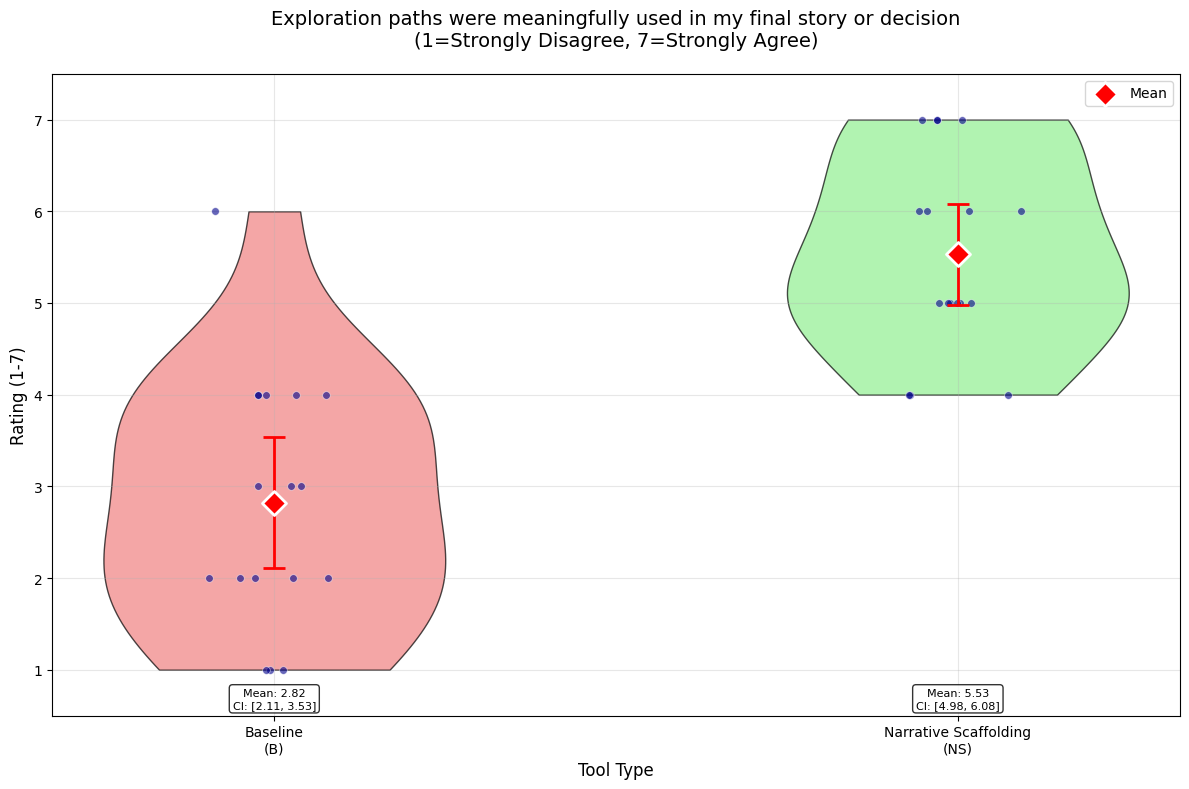


Comparison Summary with 95% Confidence Intervals:
Baseline Tool (B-19_2) Mean: 2.82, CI: [2.11, 3.53]
Narrative Scaffolding (NS-19_2) Mean: 5.53, CI: [4.98, 6.08]
Difference (NS-19_2 - B-19_2): 2.71


In [37]:
# Create violin plot comparison for B-19_2/NS-19_2
plt.figure(figsize=(12, 8))

# Prepare data for violin plot
baseline_data_b19_2 = b19_2_scores.dropna()
novel_data_b19_2 = ns19_2_scores.dropna()

# Create combined dataset for violin plot
all_data_b19_2 = [baseline_data_b19_2, novel_data_b19_2]
positions = [1, 2]

# Create violin plot
violin_parts_b19_2 = plt.violinplot(all_data_b19_2, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching style)
colors = ['lightcoral', 'lightgreen']
for pc, color in zip(violin_parts_b19_2['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter
np.random.seed(42)  # For reproducible jitter
for j, (dataset, pos) in enumerate(zip(all_data_b19_2, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, len(dataset))
    plt.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean_b19_2 = baseline_data_b19_2.mean()
novel_mean_b19_2 = novel_data_b19_2.mean()

# 95% confidence intervals
baseline_ci_b19_2 = stats.t.interval(0.95, len(baseline_data_b19_2)-1, loc=baseline_mean_b19_2, scale=stats.sem(baseline_data_b19_2))
novel_ci_b19_2 = stats.t.interval(0.95, len(novel_data_b19_2)-1, loc=novel_mean_b19_2, scale=stats.sem(novel_data_b19_2))

# Add mean markers
plt.scatter([1], [baseline_mean_b19_2], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
plt.scatter([2], [novel_mean_b19_2], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
plt.errorbar([1], [baseline_mean_b19_2], yerr=[[baseline_mean_b19_2 - baseline_ci_b19_2[0]], [baseline_ci_b19_2[1] - baseline_mean_b19_2]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
plt.errorbar([2], [novel_mean_b19_2], yerr=[[novel_mean_b19_2 - novel_ci_b19_2[0]], [novel_ci_b19_2[1] - novel_mean_b19_2]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot
plt.xticks([1, 2], ['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
plt.title('Exploration paths were meaningfully used in my final story or decision\n(1=Strongly Disagree, 7=Strongly Agree)', fontsize=14, pad=20)
plt.ylabel('Rating (1-7)', fontsize=12)
plt.xlabel('Tool Type', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 7.5)

# Add text annotations for means and CIs
plt.text(1, 0.8, f'Mean: {baseline_mean_b19_2:.2f}\nCI: [{baseline_ci_b19_2[0]:.2f}, {baseline_ci_b19_2[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(2, 0.8, f'Mean: {novel_mean_b19_2:.2f}\nCI: [{novel_ci_b19_2[0]:.2f}, {novel_ci_b19_2[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print comparison with confidence intervals
print(f"\nComparison Summary with 95% Confidence Intervals:")
print(f"Baseline Tool (B-19_2) Mean: {baseline_mean_b19_2:.2f}, CI: [{baseline_ci_b19_2[0]:.2f}, {baseline_ci_b19_2[1]:.2f}]")
print(f"Narrative Scaffolding (NS-19_2) Mean: {novel_mean_b19_2:.2f}, CI: [{novel_ci_b19_2[0]:.2f}, {novel_ci_b19_2[1]:.2f}]")
print(f"Difference (NS-19_2 - B-19_2): {novel_mean_b19_2 - baseline_mean_b19_2:.2f}")

In [38]:
# Analysis for B-19_3 vs NS-19_3: Revisiting previous steps improve the quality of the final output
print("=== Comparison B-19_3 vs NS-19_3: Revisiting previous steps improve quality ===")

# Define mapping for agreement scale (1 = Strongly Disagree, 7 = Strongly Agree)
# Based on the actual values found in the data
agreement_mapping = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Somewhat Disagree': 3,
    'Neither Agree nor Disagree': 4,
    'Somewhat Agree': 5,
    'Agree': 6,
    'Strongly Agree': 7
}

# Extract and convert scores for B-19_3 and NS-19_3
b19_3_raw = df['B-19_3'].dropna()
ns19_3_raw = df['NS-19_3'].dropna()

print("Raw data overview:")
print(f"B-19_3 values: {b19_3_raw.value_counts().to_dict()}")
print(f"NS-19_3 values: {ns19_3_raw.value_counts().to_dict()}")

# Map text responses to numeric values
b19_3_scores = b19_3_raw.map(agreement_mapping)
ns19_3_scores = ns19_3_raw.map(agreement_mapping)

print(f"\nValid responses - Baseline (B-19_3): {len(b19_3_scores)}, Narrative Scaffolding (NS-19_3): {len(ns19_3_scores)}")
print(f"Baseline B-19_3 scores: mean={b19_3_scores.mean():.2f}, std={b19_3_scores.std():.2f}")
print(f"Narrative Scaffolding NS-19_3 scores: mean={ns19_3_scores.mean():.2f}, std={ns19_3_scores.std():.2f}")

# Check for any unmapped values
if b19_3_scores.isnull().any() or ns19_3_scores.isnull().any():
    print("Warning: Some values could not be mapped!")
    print(f"B-19_3 unmapped values: {b19_3_raw[b19_3_scores.isnull()].unique()}")
    print(f"NS-19_3 unmapped values: {ns19_3_raw[ns19_3_scores.isnull()].unique()}")

# Perform paired t-test (assuming paired data)
if len(b19_3_scores) == len(ns19_3_scores):
    diff_scores_b19_3 = ns19_3_scores.reset_index(drop=True) - b19_3_scores.reset_index(drop=True)
    
    # Paired t-test
    t_stat_b19_3, p_value_b19_3 = stats.ttest_rel(ns19_3_scores, b19_3_scores)
    
    # Wilcoxon signed-rank test (non-parametric alternative)
    wilcoxon_stat_b19_3, wilcoxon_p_b19_3 = stats.wilcoxon(ns19_3_scores, b19_3_scores)
    
    # Calculate Cohen's d for effect size
    pooled_std = np.sqrt(((len(b19_3_scores)-1)*b19_3_scores.std()**2 + (len(ns19_3_scores)-1)*ns19_3_scores.std()**2) / (len(b19_3_scores)+len(ns19_3_scores)-2))
    cohen_d_b19_3 = (ns19_3_scores.mean() - b19_3_scores.mean()) / pooled_std
    
    print(f"\nPaired t-test: t-statistic = {t_stat_b19_3:.4f}, p-value = {p_value_b19_3:.4f}")
    print(f"Wilcoxon signed-rank test: statistic = {wilcoxon_stat_b19_3:.4f}, p-value = {wilcoxon_p_b19_3:.4f}")
    print(f"Cohen's d (effect size): {cohen_d_b19_3:.4f}")
    
    # Effect size interpretation
    if abs(cohen_d_b19_3) < 0.2:
        effect_size_label_b19_3 = "negligible"
    elif abs(cohen_d_b19_3) < 0.5:
        effect_size_label_b19_3 = "small" 
    elif abs(cohen_d_b19_3) < 0.8:
        effect_size_label_b19_3 = "medium"
    else:
        effect_size_label_b19_3 = "large"
    
    significance_b19_3 = "significant" if p_value_b19_3 < 0.05 else "not significant"
    improvement_b19_3 = f"{ns19_3_scores.mean() - b19_3_scores.mean():+.2f}"
    
    print(f"Difference: {improvement_b19_3} points (Narrative Scaffolding - Baseline)")
    print(f"Statistical significance: {significance_b19_3} (α = 0.05)")
    print(f"Effect size: {effect_size_label_b19_3}")
    
else:
    print("Unequal sample sizes - using independent samples t-test")
    t_stat_b19_3, p_value_b19_3 = stats.ttest_ind(ns19_3_scores, b19_3_scores)
    print(f"Independent t-test: t-statistic = {t_stat_b19_3:.4f}, p-value = {p_value_b19_3:.4f}")

=== Comparison B-19_3 vs NS-19_3: Revisiting previous steps improve quality ===
Raw data overview:
B-19_3 values: {'Somewhat Disagree': 5, 'Strongly Disagree': 4, 'Neither Agree nor Disagree': 4, 'Disagree': 4}
NS-19_3 values: {'Agree': 7, 'Strongly Agree': 6, 'Somewhat Agree': 3, 'Neither Agree nor Disagree': 1}

Valid responses - Baseline (B-19_3): 17, Narrative Scaffolding (NS-19_3): 17
Baseline B-19_3 scores: mean=2.53, std=1.12
Narrative Scaffolding NS-19_3 scores: mean=6.06, std=0.90

Paired t-test: t-statistic = 11.8240, p-value = 0.0000
Wilcoxon signed-rank test: statistic = 0.0000, p-value = 0.0000
Cohen's d (effect size): 3.4663
Difference: +3.53 points (Narrative Scaffolding - Baseline)
Statistical significance: significant (α = 0.05)
Effect size: large


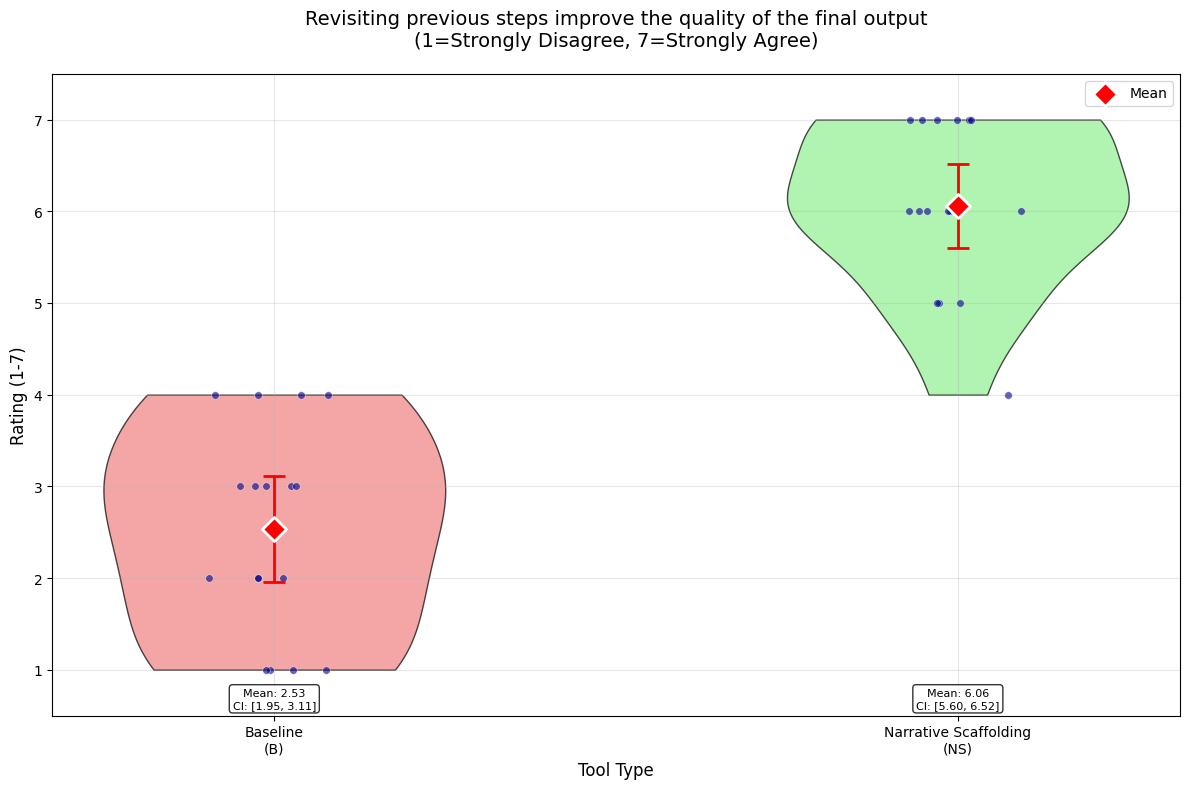


Comparison Summary with 95% Confidence Intervals:
Baseline Tool (B-19_3) Mean: 2.53, CI: [1.95, 3.11]
Narrative Scaffolding (NS-19_3) Mean: 6.06, CI: [5.60, 6.52]
Difference (NS-19_3 - B-19_3): 3.53


In [39]:
# Create violin plot comparison for B-19_3/NS-19_3
plt.figure(figsize=(12, 8))

# Prepare data for violin plot
baseline_data_b19_3 = b19_3_scores.dropna()
novel_data_b19_3 = ns19_3_scores.dropna()

# Create combined dataset for violin plot
all_data_b19_3 = [baseline_data_b19_3, novel_data_b19_3]
positions = [1, 2]

# Create violin plot
violin_parts_b19_3 = plt.violinplot(all_data_b19_3, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching style)
colors = ['lightcoral', 'lightgreen']
for pc, color in zip(violin_parts_b19_3['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter
np.random.seed(42)  # For reproducible jitter
for j, (dataset, pos) in enumerate(zip(all_data_b19_3, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, len(dataset))
    plt.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean_b19_3 = baseline_data_b19_3.mean()
novel_mean_b19_3 = novel_data_b19_3.mean()

# 95% confidence intervals
baseline_ci_b19_3 = stats.t.interval(0.95, len(baseline_data_b19_3)-1, loc=baseline_mean_b19_3, scale=stats.sem(baseline_data_b19_3))
novel_ci_b19_3 = stats.t.interval(0.95, len(novel_data_b19_3)-1, loc=novel_mean_b19_3, scale=stats.sem(novel_data_b19_3))

# Add mean markers
plt.scatter([1], [baseline_mean_b19_3], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
plt.scatter([2], [novel_mean_b19_3], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
plt.errorbar([1], [baseline_mean_b19_3], yerr=[[baseline_mean_b19_3 - baseline_ci_b19_3[0]], [baseline_ci_b19_3[1] - baseline_mean_b19_3]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
plt.errorbar([2], [novel_mean_b19_3], yerr=[[novel_mean_b19_3 - novel_ci_b19_3[0]], [novel_ci_b19_3[1] - novel_mean_b19_3]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot
plt.xticks([1, 2], ['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
plt.title('Revisiting previous steps improve the quality of the final output\n(1=Strongly Disagree, 7=Strongly Agree)', fontsize=14, pad=20)
plt.ylabel('Rating (1-7)', fontsize=12)
plt.xlabel('Tool Type', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 7.5)

# Add text annotations for means and CIs
plt.text(1, 0.8, f'Mean: {baseline_mean_b19_3:.2f}\nCI: [{baseline_ci_b19_3[0]:.2f}, {baseline_ci_b19_3[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(2, 0.8, f'Mean: {novel_mean_b19_3:.2f}\nCI: [{novel_ci_b19_3[0]:.2f}, {novel_ci_b19_3[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print comparison with confidence intervals
print(f"\nComparison Summary with 95% Confidence Intervals:")
print(f"Baseline Tool (B-19_3) Mean: {baseline_mean_b19_3:.2f}, CI: [{baseline_ci_b19_3[0]:.2f}, {baseline_ci_b19_3[1]:.2f}]")
print(f"Narrative Scaffolding (NS-19_3) Mean: {novel_mean_b19_3:.2f}, CI: [{novel_ci_b19_3[0]:.2f}, {novel_ci_b19_3[1]:.2f}]")
print(f"Difference (NS-19_3 - B-19_3): {novel_mean_b19_3 - baseline_mean_b19_3:.2f}")

In [40]:
# Statistical Tests for B-17/NS-17 and B-19/NS-19 Comparisons
print("\n" + "=" * 80)
print("STATISTICAL TESTS FOR ADDITIONAL USABILITY COMPARISONS")
print("=" * 80)

additional_results = {}

# Test 1: B-17_1 vs NS-17_1 (Defend reasoning behind insights)
print("\n1. DEFEND REASONING BEHIND THE INSIGHTS GENERATED (B-17 vs NS-17)")
print("-" * 70)

baseline_b17 = b17_scores.dropna()
novel_b17 = ns17_scores.dropna()

# Paired t-test
t_stat_b17, p_value_b17 = stats.ttest_rel(baseline_b17, novel_b17)

# Effect size (Cohen's d for paired samples)
diff_scores_b17 = novel_b17 - baseline_b17
cohen_d_b17 = diff_scores_b17.mean() / diff_scores_b17.std()

# Wilcoxon signed-rank test
wilcoxon_stat_b17, wilcoxon_p_b17 = stats.wilcoxon(baseline_b17, novel_b17)

additional_results['17'] = {
    'question': 'Defend Reasoning Behind Insights',
    'baseline_mean': baseline_b17.mean(),
    'novel_mean': novel_b17.mean(),
    'mean_diff': novel_b17.mean() - baseline_b17.mean(),
    't_stat': t_stat_b17,
    'p_value': p_value_b17,
    'cohen_d': cohen_d_b17,
    'wilcoxon_p': wilcoxon_p_b17
}

print(f"Paired t-test:")
print(f"  t-statistic: {t_stat_b17:.4f}")
print(f"  p-value: {p_value_b17:.6f}")
print(f"  Effect size (Cohen's d): {cohen_d_b17:.4f}")

print(f"Wilcoxon signed-rank test:")
print(f"  p-value: {wilcoxon_p_b17:.6f}")

# Test 2: B-19_1 vs NS-19_1 (Confident presenting conclusions)
print("\n\n2. CONFIDENT PRESENTING YOUR CONCLUSIONS TO OTHERS (B-19 vs NS-19)")
print("-" * 70)

baseline_b19 = b19_scores.dropna()
novel_b19 = ns19_scores.dropna()

# Paired t-test
t_stat_b19, p_value_b19 = stats.ttest_rel(baseline_b19, novel_b19)

# Effect size (Cohen's d for paired samples)
diff_scores_b19 = novel_b19 - baseline_b19
cohen_d_b19 = diff_scores_b19.mean() / diff_scores_b19.std()

# Wilcoxon signed-rank test
wilcoxon_stat_b19, wilcoxon_p_b19 = stats.wilcoxon(baseline_b19, novel_b19)

additional_results['19'] = {
    'question': 'Confident Presenting Conclusions',
    'baseline_mean': baseline_b19.mean(),
    'novel_mean': novel_b19.mean(),
    'mean_diff': novel_b19.mean() - baseline_b19.mean(),
    't_stat': t_stat_b19,
    'p_value': p_value_b19,
    'cohen_d': cohen_d_b19,
    'wilcoxon_p': wilcoxon_p_b19
}

print(f"Paired t-test:")
print(f"  t-statistic: {t_stat_b19:.4f}")
print(f"  p-value: {p_value_b19:.6f}")
print(f"  Effect size (Cohen's d): {cohen_d_b19:.4f}")

print(f"Wilcoxon signed-rank test:")
print(f"  p-value: {wilcoxon_p_b19:.6f}")

# Summary table
print(f"\n\n" + "=" * 95)
print("ADDITIONAL USABILITY MEASURES STATISTICAL SUMMARY")
print("=" * 95)
cohens_d_label = "Cohen's d"
print(f"{'Question':<35} {'B Mean':<8} {'NS Mean':<8} {'Diff':<8} {'p-value':<10} {cohens_d_label:<10} {'Sig':<5} {'Winner':<10}")
print("-" * 95)

for q_num, results in additional_results.items():
    significance = "***" if results['p_value'] < 0.001 else "**" if results['p_value'] < 0.01 else "*" if results['p_value'] < 0.05 else "ns"
    
    # Determine winner (higher is better for these usability questions)
    if results['novel_mean'] > results['baseline_mean']:
        winner = "Novel" if results['p_value'] < 0.05 else "Novel (ns)"
    elif results['novel_mean'] < results['baseline_mean']:
        winner = "Baseline" if results['p_value'] < 0.05 else "Base (ns)"
    else:
        winner = "Tie"
    
    print(f"{results['question']:<35} {results['baseline_mean']:<8.2f} {results['novel_mean']:<8.2f} "
          f"{results['mean_diff']:<+8.2f} {results['p_value']:<10.6f} {results['cohen_d']:<10.3f} {significance:<5} {winner:<10}")

print(f"\nInterpretation:")
print(f"• Higher scores = Better performance for usability measures")
print(f"• Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print(f"• Winner column shows which system performs better (if significant)")

# Key findings
print(f"\nKey Additional Usability Findings:")
significant_results_additional = []
for q_num, results in additional_results.items():
    question = results['question']
    diff = results['mean_diff']
    p_val = results['p_value']
    
    if p_val < 0.05:
        if diff > 0:  # Narrative Scaffolding has higher scores = better
            interpretation = "Narrative Scaffolding BETTER"
            significant_results_additional.append(f"✓ {question}: {interpretation} (diff: +{diff:.2f}, p: {p_val:.3f})")
        else:  # Narrative Scaffolding has lower scores = worse
            interpretation = "Baseline Tool BETTER"
            significant_results_additional.append(f"✗ {question}: {interpretation} (diff: {diff:.2f}, p: {p_val:.3f})")
    else:
        significant_results_additional.append(f"≈ {question}: No significant difference (diff: {diff:+.2f}, p: {p_val:.3f})")

for result in significant_results_additional:
    print(result)


STATISTICAL TESTS FOR ADDITIONAL USABILITY COMPARISONS

1. DEFEND REASONING BEHIND THE INSIGHTS GENERATED (B-17 vs NS-17)
----------------------------------------------------------------------
Paired t-test:
  t-statistic: -4.3377
  p-value: 0.000509
  Effect size (Cohen's d): 1.0521
Wilcoxon signed-rank test:
  p-value: 0.001678


2. CONFIDENT PRESENTING YOUR CONCLUSIONS TO OTHERS (B-19 vs NS-19)
----------------------------------------------------------------------
Paired t-test:
  t-statistic: -1.5332
  p-value: 0.144751
  Effect size (Cohen's d): 0.3719
Wilcoxon signed-rank test:
  p-value: 0.148063


ADDITIONAL USABILITY MEASURES STATISTICAL SUMMARY
Question                            B Mean   NS Mean  Diff     p-value    Cohen's d  Sig   Winner    
-----------------------------------------------------------------------------------------------
Defend Reasoning Behind Insights    3.41     5.88     +2.47    0.000509   1.052      ***   Novel     
Confident Presenting Conclusions    

In [41]:
# Group Analysis: B-19 vs NS-19 by Baseline Assignment
print("=" * 80)
print("GROUP ANALYSIS: B-19 vs NS-19 Separated by Baseline Assignment")
print("=" * 80)

# Use the processed scores that were already calculated earlier in the notebook
# From the variables, we can see b19_scores and ns19_scores are available
print("Using previously calculated b19_scores and ns19_scores")

# Separate participants into two groups based on their Baseline assignment
group1_indices = df[df['Baseline'] == 1].index  # Baseline Tool first
group2_indices = df[df['Baseline'] == 2].index  # Narrative Scaffolding first

print(f"\nGroup 1 (Baseline Tool First): n = {len(group1_indices)}")
print(f"Group 2 (Narrative Scaffolding First): n = {len(group2_indices)}")

# Function to perform paired t-test and calculate effect size
def analyze_group(group_indices, group_name, baseline_scores, novel_scores):
    print(f"\n{'-' * 60}")
    print(f"{group_name} - B-19 vs NS-19 Analysis")
    print(f"{'-' * 60}")
    
    # Extract scores for this group
    baseline_group = baseline_scores[group_indices]
    novel_group = novel_scores[group_indices]
    
    # Calculate descriptive statistics
    baseline_mean = baseline_group.mean()
    novel_mean = novel_group.mean()
    mean_diff = novel_mean - baseline_mean
    
    baseline_std = baseline_group.std()
    novel_std = novel_group.std()
    
    print(f"Baseline Tool (B-19): Mean = {baseline_mean:.2f}, SD = {baseline_std:.2f}")
    print(f"Narrative Scaffolding (NS-19): Mean = {novel_mean:.2f}, SD = {novel_std:.2f}")
    print(f"Mean Difference (NS-19 - B-19): {mean_diff:.2f}")
    
    # Perform paired t-test
    t_stat, p_value = stats.ttest_rel(novel_group, baseline_group)
    
    # Calculate Cohen's d for paired samples
    diff_scores = novel_group - baseline_group
    cohen_d = diff_scores.mean() / diff_scores.std()
    
    # Determine significance and effect size interpretation
    significance = "Yes" if p_value < 0.05 else "No"
    
    if abs(cohen_d) < 0.2:
        effect_size_label = "Negligible"
    elif abs(cohen_d) < 0.5:
        effect_size_label = "Small"
    elif abs(cohen_d) < 0.8:
        effect_size_label = "Medium"
    else:
        effect_size_label = "Large"
    
    improvement = "Narrative Scaffolding" if mean_diff > 0 else "Baseline Tool"
    
    print(f"\nPaired t-test results:")
    print(f"  t-statistic: {t_stat:.3f}")
    print(f"  p-value: {p_value:.3f}")
    print(f"  Significant (p < 0.05): {significance}")
    print(f"  Cohen's d: {cohen_d:.3f} ({effect_size_label})")
    print(f"  Better performing system: {improvement}")
    
    # Wilcoxon signed-rank test (non-parametric alternative)
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(novel_group, baseline_group, alternative='two-sided')
    print(f"\nWilcoxon signed-rank test:")
    print(f"  Statistic: {wilcoxon_stat:.3f}")
    print(f"  p-value: {wilcoxon_p:.3f}")
    
    return {
        'group': group_name,
        'n': len(group_indices),
        'baseline_mean': baseline_mean,
        'novel_mean': novel_mean,
        'mean_diff': mean_diff,
        't_stat': t_stat,
        'p_value': p_value,
        'cohen_d': cohen_d,
        'significance': significance,
        'effect_size': effect_size_label,
        'better_system': improvement,
        'wilcoxon_p': wilcoxon_p
    }

# Analyze both groups
group1_results = analyze_group(group1_indices, "Group 1 (Baseline Tool First)", b19_scores, ns19_scores)
group2_results = analyze_group(group2_indices, "Group 2 (Narrative Scaffolding First)", b19_scores, ns19_scores)

# Summary comparison
print(f"\n{'=' * 80}")
print("SUMMARY COMPARISON BETWEEN GROUPS")
print(f"{'=' * 80}")

print(f"\n{'Metric':<25} {'Group 1 (BT First)':<20} {'Group 2 (NS First)':<20}")
print(f"{'-' * 65}")
print(f"{'Sample Size':<25} {group1_results['n']:<20} {group2_results['n']:<20}")
print(f"{'B-19 Mean':<25} {group1_results['baseline_mean']:<20.2f} {group2_results['baseline_mean']:<20.2f}")
print(f"{'NS-19 Mean':<25} {group1_results['novel_mean']:<20.2f} {group2_results['novel_mean']:<20.2f}")
print(f"{'Mean Difference':<25} {group1_results['mean_diff']:<20.2f} {group2_results['mean_diff']:<20.2f}")
print(f"{'t-statistic':<25} {group1_results['t_stat']:<20.3f} {group2_results['t_stat']:<20.3f}")
print(f"{'p-value':<25} {group1_results['p_value']:<20.3f} {group2_results['p_value']:<20.3f}")
print(f"{'Significant':<25} {group1_results['significance']:<20} {group2_results['significance']:<20}")
cohens_d_label = "Cohen's d"
print(f"{cohens_d_label:<25} {group1_results['cohen_d']:<20.3f} {group2_results['cohen_d']:<20.3f}")
print(f"{'Effect Size':<25} {group1_results['effect_size']:<20} {group2_results['effect_size']:<20}")
print(f"{'Better System':<25} {group1_results['better_system']:<20} {group2_results['better_system']:<20}")

# Additional insights
print(f"\n{'=' * 80}")
print("KEY INSIGHTS")
print(f"{'=' * 80}")

if group1_results['significance'] == 'Yes' and group2_results['significance'] == 'No':
    print("• Significant improvement in confidence (B-19 → NS-19) was found ONLY in Group 1 (Baseline Tool First)")
    print("• Group 2 (Narrative Scaffolding First) showed no significant improvement")
    print("• This suggests a potential ORDER EFFECT where using Baseline Tool first enhances")
    print("  appreciation of Narrative Scaffolding's confidence-building capabilities")
elif group1_results['significance'] == 'No' and group2_results['significance'] == 'Yes':
    print("• Significant improvement in confidence (B-19 → NS-19) was found ONLY in Group 2 (Narrative Scaffolding First)")
    print("• Group 1 (Baseline Tool First) showed no significant improvement")
    print("• This suggests Narrative Scaffolding's benefits are more apparent when experienced first")
elif group1_results['significance'] == 'Yes' and group2_results['significance'] == 'Yes':
    print("• Both groups showed significant improvement in confidence (B-19 → NS-19)")
    print("• The order of tool exposure did not affect the significance of improvement")
    print("• Narrative Scaffolding consistently enhances confidence regardless of presentation order")
else:
    print("• Neither group showed significant improvement in confidence (B-19 → NS-19)")
    print("• The lack of significance in the overall analysis is consistent across both")
    print("  presentation orders, suggesting the null result is robust")

print(f"\nEffect size comparison:")
print(f"• Group 1 effect size: {group1_results['cohen_d']:.3f} ({group1_results['effect_size']})")
print(f"• Group 2 effect size: {group2_results['cohen_d']:.3f} ({group2_results['effect_size']})")

if abs(group1_results['cohen_d']) > abs(group2_results['cohen_d']):
    stronger_group = "Group 1 (Baseline Tool First)"
    stronger_effect = abs(group1_results['cohen_d'])
    weaker_effect = abs(group2_results['cohen_d'])
else:
    stronger_group = "Group 2 (Narrative Scaffolding First)"
    stronger_effect = abs(group2_results['cohen_d'])
    weaker_effect = abs(group1_results['cohen_d'])

print(f"• {stronger_group} showed a stronger effect size")
print(f"  (|{stronger_effect:.3f}| vs |{weaker_effect:.3f}|)")

GROUP ANALYSIS: B-19 vs NS-19 Separated by Baseline Assignment
Using previously calculated b19_scores and ns19_scores

Group 1 (Baseline Tool First): n = 8
Group 2 (Narrative Scaffolding First): n = 9

------------------------------------------------------------
Group 1 (Baseline Tool First) - B-19 vs NS-19 Analysis
------------------------------------------------------------
Baseline Tool (B-19): Mean = 6.25, SD = 0.46
Narrative Scaffolding (NS-19): Mean = 5.50, SD = 1.20
Mean Difference (NS-19 - B-19): -0.75

Paired t-test results:
  t-statistic: -1.655
  p-value: 0.142
  Significant (p < 0.05): No
  Cohen's d: -0.585 (Medium)
  Better performing system: Baseline Tool

Wilcoxon signed-rank test:
  Statistic: 2.000
  p-value: 0.131

------------------------------------------------------------
Group 2 (Narrative Scaffolding First) - B-19 vs NS-19 Analysis
------------------------------------------------------------
Baseline Tool (B-19): Mean = 4.00, SD = 1.66
Narrative Scaffolding (NS-

/Users/h2o/Documents/Projects/Research/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/Users/h2o/Documents/Projects/Research/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


In [42]:
# SUS (System Usability Scale) Analysis
print("=" * 80)
print("SYSTEM USABILITY SCALE (SUS) ANALYSIS")
print("=" * 80)

# Check for SUS columns in the dataset
sus_columns = [col for col in df.columns if col.startswith('SUS-')]
print(f"Available SUS columns: {sus_columns}")

if len(sus_columns) == 0:
    print("No SUS columns found. Let me check for alternative naming patterns...")
    # Check for alternative patterns
    alternative_sus = [col for col in df.columns if 'SUS' in col.upper()]
    print(f"Alternative SUS patterns found: {alternative_sus}")
else:
    print(f"Found {len(sus_columns)} SUS questions")

# If we have SUS columns, proceed with analysis
if len(sus_columns) > 0:
    # Display basic info about SUS data
    print(f"\nSUS Data Overview:")
    for col in sus_columns:
        unique_vals = df[col].unique()
        print(f"{col}: {sorted([v for v in unique_vals if pd.notna(v)])}")
else:
    print("Cannot proceed without SUS columns in the dataset.")

SYSTEM USABILITY SCALE (SUS) ANALYSIS
Available SUS columns: ['SUS-1', 'SUS-2', 'SUS-3', 'SUS-4', 'SUS-5', 'SUS-6', 'SUS-7', 'SUS-8', 'SUS-9', 'SUS-10']
Found 10 SUS questions

SUS Data Overview:
SUS-1: [4, 5]
SUS-2: [3, 4, 5]
SUS-3: [3, 4, 5]
SUS-4: [3, 4]
SUS-5: [3, 4, 5]
SUS-6: [1, 2, 3]
SUS-7: [1, 2, 3]
SUS-8: [1, 2, 3]
SUS-9: [1, 2, 3]
SUS-10: [1, 2, 3]


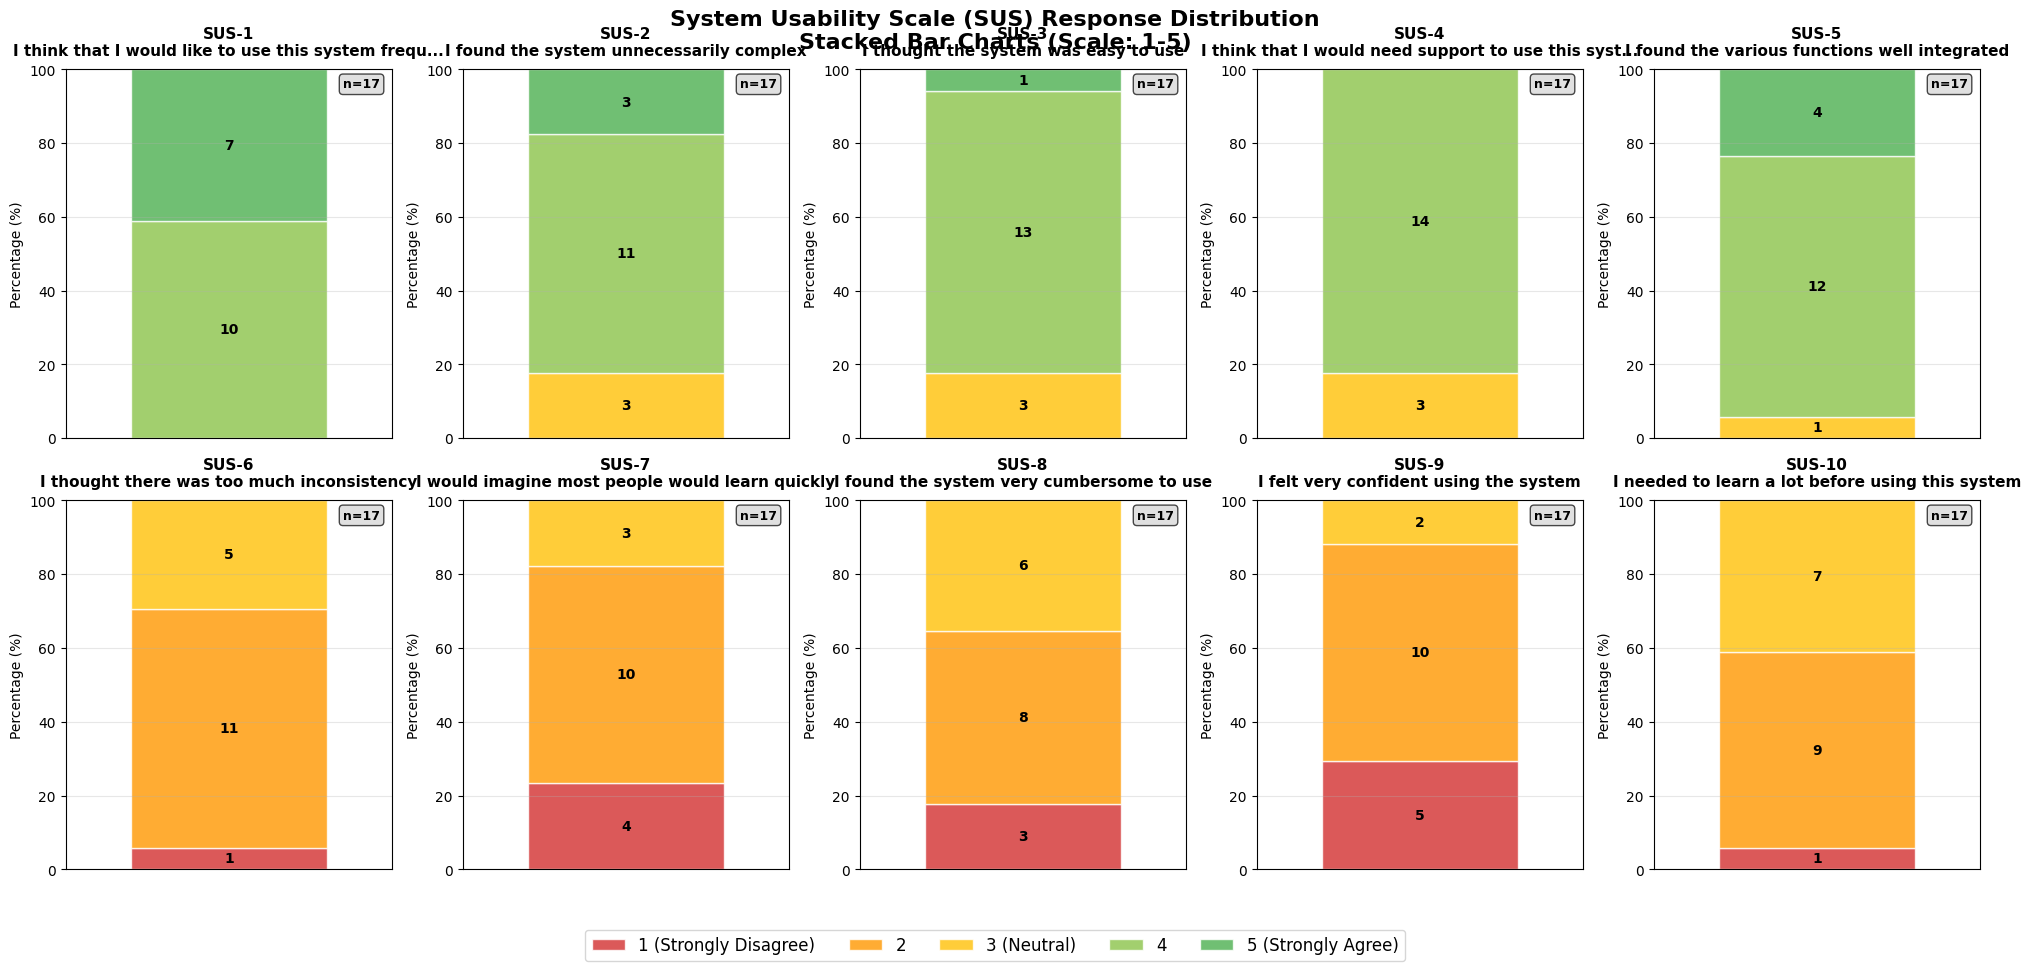


SUS RESPONSE SUMMARY STATISTICS
Question Mean   SD     Mode   n    Distribution (1→5)       
--------------------------------------------------------------------------------
SUS-1    4.41   0.51   4      17   1:0 2:0 3:0 4:10 5:7     
SUS-2    4.00   0.61   4      17   1:0 2:0 3:3 4:11 5:3     
SUS-3    3.88   0.49   4      17   1:0 2:0 3:3 4:13 5:1     
SUS-4    3.82   0.39   4      17   1:0 2:0 3:3 4:14 5:0     
SUS-5    4.18   0.53   4      17   1:0 2:0 3:1 4:12 5:4     
SUS-6    2.24   0.56   2      17   1:1 2:11 3:5 4:0 5:0     
SUS-7    1.94   0.66   2      17   1:4 2:10 3:3 4:0 5:0     
SUS-8    2.18   0.73   2      17   1:3 2:8 3:6 4:0 5:0      
SUS-9    1.82   0.64   2      17   1:5 2:10 3:2 4:0 5:0     
SUS-10   2.35   0.61   2      17   1:1 2:9 3:7 4:0 5:0      


In [43]:
# SUS Stacked Bar Charts
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# SUS Question definitions for better labeling
sus_questions = {
    'SUS-1': 'I think that I would like to use this system frequently',
    'SUS-2': 'I found the system unnecessarily complex',
    'SUS-3': 'I thought the system was easy to use',
    'SUS-4': 'I think that I would need support to use this system',
    'SUS-5': 'I found the various functions well integrated',
    'SUS-6': 'I thought there was too much inconsistency',
    'SUS-7': 'I would imagine most people would learn quickly',
    'SUS-8': 'I found the system very cumbersome to use',
    'SUS-9': 'I felt very confident using the system',
    'SUS-10': 'I needed to learn a lot before using this system'
}

# Color scheme for 1-5 scale (1=red to 5=green)
colors = ['#d32f2f', '#ff9800', '#ffc107', '#8bc34a', '#4caf50']  # Red to Green
scale_labels = ['1 (Strongly Disagree)', '2', '3 (Neutral)', '4', '5 (Strongly Agree)']

# Create figure with subplots (2 rows, 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('System Usability Scale (SUS) Response Distribution\nStacked Bar Charts (Scale: 1-5)', 
             fontsize=16, fontweight='bold', y=0.98)

# Flatten axes for easier iteration
axes = axes.flatten()

for i, sus_col in enumerate(sus_columns):
    ax = axes[i]
    
    # Count responses for each scale value
    response_counts = Counter(df[sus_col].dropna())
    
    # Ensure all scale values 1-5 are represented
    scale_counts = [response_counts.get(j, 0) for j in range(1, 6)]
    scale_percentages = [count/sum(scale_counts)*100 if sum(scale_counts) > 0 else 0 for count in scale_counts]
    
    # Create stacked bar
    bottom = 0
    bars = []
    for j, (count, percentage) in enumerate(zip(scale_counts, scale_percentages)):
        if count > 0:  # Only plot if there are responses
            bar = ax.bar(0, percentage, bottom=bottom, color=colors[j], 
                        alpha=0.8, width=0.6, edgecolor='white', linewidth=1)
            bars.append(bar)
            
            # Add count labels if percentage is significant enough
            if percentage > 5:  # Only label if > 5%
                ax.text(0, bottom + percentage/2, f'{count}', 
                       ha='center', va='center', fontweight='bold', fontsize=10)
            
            bottom += percentage
    
    # Customize the subplot
    ax.set_title(f'{sus_col}\n{sus_questions[sus_col][:50]}{"..." if len(sus_questions[sus_col]) > 50 else ""}', 
                fontsize=11, fontweight='bold', pad=10)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Percentage (%)', fontsize=10)
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3)
    
    # Add response count
    total_responses = sum(scale_counts)
    ax.text(0.35, 95, f'n={total_responses}', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))

# Create a single legend for all subplots
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[i], alpha=0.8, edgecolor='white') 
                  for i in range(5)]
fig.legend(legend_elements, scale_labels, loc='lower center', ncol=5, 
          bbox_to_anchor=(0.5, 0.02), fontsize=12, frameon=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12, top=0.92)
plt.show()

# Print summary statistics
print(f"\n{'='*80}")
print("SUS RESPONSE SUMMARY STATISTICS")
print(f"{'='*80}")

print(f"{'Question':<8} {'Mean':<6} {'SD':<6} {'Mode':<6} {'n':<4} {'Distribution (1→5)':<25}")
print("-" * 80)

for sus_col in sus_columns:
    data = df[sus_col].dropna()
    if len(data) > 0:
        mean_score = data.mean()
        std_score = data.std()
        mode_score = data.mode().iloc[0] if len(data.mode()) > 0 else 'N/A'
        n_responses = len(data)
        
        # Distribution string
        response_counts = Counter(data)
        dist_str = ' '.join([f"{i}:{response_counts.get(i, 0)}" for i in range(1, 6)])
        
        print(f"{sus_col:<8} {mean_score:<6.2f} {std_score:<6.2f} {mode_score:<6} {n_responses:<4} {dist_str:<25}")

In [44]:
# CORRECTED SUS Score Calculation - Alternative Method
print("=" * 80)
print("CORRECTED SUS SCORE CALCULATION")
print("=" * 80)

# Method as described:
# - For SUS-1 to SUS-5: multiply mean by 20 directly
# - For SUS-6 to SUS-10: reverse scale (1→5, 2→4, 3→3, 4→2, 5→1), then multiply by 20
# - Average all 10 results for final SUS score

print("Step-by-step calculation:")
print("-" * 50)

# Calculate means for each question
question_means = {}
transformed_scores = {}

print("SUS-1 to SUS-5 (positive questions - direct scaling):")
for i in range(1, 6):
    col = f'SUS-{i}'
    mean_val = df[col].mean()
    transformed_score = mean_val * 20
    question_means[col] = mean_val
    transformed_scores[col] = transformed_score
    print(f"{col}: Mean = {mean_val:.2f} → Score = {mean_val:.2f} × 20 = {transformed_score:.1f}")

print(f"\nSUS-6 to SUS-10 (negative questions - reverse scale then multiply by 20):")
for i in range(6, 11):
    col = f'SUS-{i}'
    mean_val = df[col].mean()
    # Reverse the scale: 1→5, 2→4, 3→3, 4→2, 5→1
    reversed_mean = 6 - mean_val
    transformed_score = reversed_mean * 20
    question_means[col] = mean_val
    transformed_scores[col] = transformed_score
    print(f"{col}: Mean = {mean_val:.2f} → Reversed = {reversed_mean:.2f} → Score = {reversed_mean:.2f} × 20 = {transformed_score:.1f}")

# Calculate final SUS score as average of all 10 transformed scores
final_sus_score = sum(transformed_scores.values()) / len(transformed_scores)

print(f"\n{'='*50}")
print("FINAL SUS SCORE CALCULATION:")
print(f"{'='*50}")

print("Individual question scores:")
for col in sus_columns:
    print(f"{col}: {transformed_scores[col]:5.1f}")

print(f"\nSum of all scores: {sum(transformed_scores.values()):.1f}")
print(f"Number of questions: {len(transformed_scores)}")
print(f"Final SUS Score: {sum(transformed_scores.values()):.1f} ÷ {len(transformed_scores)} = {final_sus_score:.1f}")

print(f"\n{'='*50}")
print("INTERPRETATION:")
print(f"{'='*50}")
print(f"SUS Score: {final_sus_score:.1f}")

# Standard SUS interpretation
if final_sus_score >= 90:
    grade = "A+ (Excellent)"
elif final_sus_score >= 80:
    grade = "A- to A (Good)"
elif final_sus_score >= 70:
    grade = "B- to B+ (Okay)"
elif final_sus_score >= 60:
    grade = "C- to C+ (Poor)"
else:
    grade = "D to F (Awful)"

print(f"Grade: {grade}")

# Industry benchmarks
print(f"\nBenchmarks:")
print(f"• Industry Average: 68")
print(f"• Your Score: {final_sus_score:.1f}")
if final_sus_score > 68:
    print(f"• Performance: {final_sus_score - 68:.1f} points ABOVE industry average ✓")
else:
    print(f"• Performance: {68 - final_sus_score:.1f} points BELOW industry average")

print(f"\nDetailed breakdown by question type:")
positive_scores = [transformed_scores[f'SUS-{i}'] for i in [1, 3, 5, 7, 9]]
negative_scores = [transformed_scores[f'SUS-{i}'] for i in [2, 4, 6, 8, 10]]

print(f"• Positive questions average (SUS-1,3,5,7,9): {sum(positive_scores)/len(positive_scores):.1f}")
print(f"• Negative questions average (SUS-2,4,6,8,10): {sum(negative_scores)/len(negative_scores):.1f}")

# Compare with previous calculation
print(f"\n{'='*50}")
print("COMPARISON WITH PREVIOUS METHOD:")
print(f"{'='*50}")
if 'SUS_Score' in df.columns:
    previous_mean = df['SUS_Score'].mean()
    print(f"Previous calculation (standard method): {previous_mean:.1f}")
    print(f"New calculation (your method): {final_sus_score:.1f}")
    print(f"Difference: {final_sus_score - previous_mean:.1f} points")
else:
    print("No previous SUS calculation found for comparison.")

CORRECTED SUS SCORE CALCULATION
Step-by-step calculation:
--------------------------------------------------
SUS-1 to SUS-5 (positive questions - direct scaling):
SUS-1: Mean = 4.41 → Score = 4.41 × 20 = 88.2
SUS-2: Mean = 4.00 → Score = 4.00 × 20 = 80.0
SUS-3: Mean = 3.88 → Score = 3.88 × 20 = 77.6
SUS-4: Mean = 3.82 → Score = 3.82 × 20 = 76.5
SUS-5: Mean = 4.18 → Score = 4.18 × 20 = 83.5

SUS-6 to SUS-10 (negative questions - reverse scale then multiply by 20):
SUS-6: Mean = 2.24 → Reversed = 3.76 → Score = 3.76 × 20 = 75.3
SUS-7: Mean = 1.94 → Reversed = 4.06 → Score = 4.06 × 20 = 81.2
SUS-8: Mean = 2.18 → Reversed = 3.82 → Score = 3.82 × 20 = 76.5
SUS-9: Mean = 1.82 → Reversed = 4.18 → Score = 4.18 × 20 = 83.5
SUS-10: Mean = 2.35 → Reversed = 3.65 → Score = 3.65 × 20 = 72.9

FINAL SUS SCORE CALCULATION:
Individual question scores:
SUS-1:  88.2
SUS-2:  80.0
SUS-3:  77.6
SUS-4:  76.5
SUS-5:  83.5
SUS-6:  75.3
SUS-7:  81.2
SUS-8:  76.5
SUS-9:  83.5
SUS-10:  72.9

Sum of all scores: 79